# RSS Change for a Given Gamma

Examines how the RSS of packets changes while the angle the transmitter faces when it transmits those packets remains constant.

For the `Range Trials/` experiments, the tag didn't move at all, meaning there should be very little change.

In [1]:
from BleFinley import *
from ble_logs import BleLogStatic

tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5)

## Examine Range Trial 7

Look at the difference in RSS just for gamma = 0, and then look at a combined histogram of all angles from 0-360 degrees.

BleLog | tx: c, no.packets: 1533, time: 86.140s


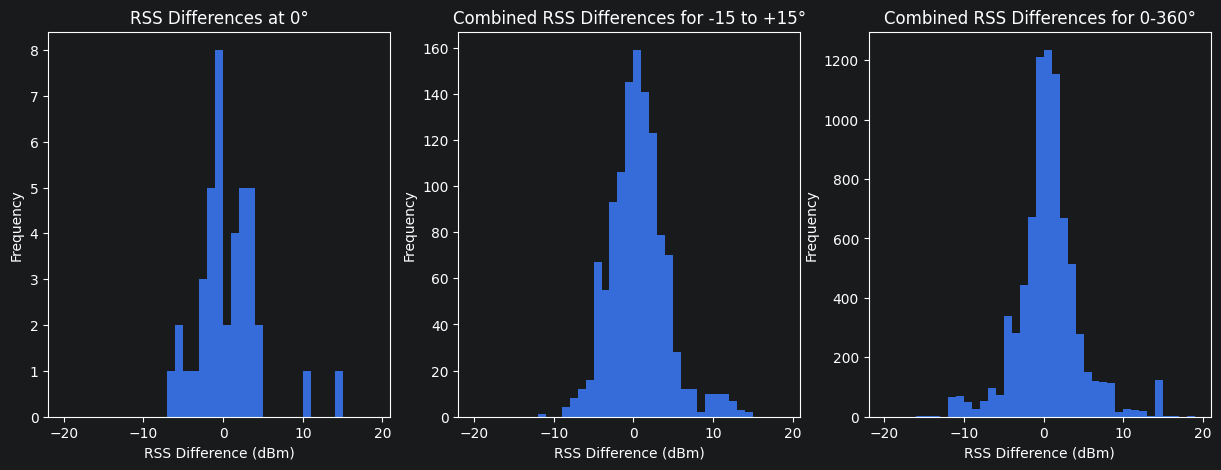

In [2]:
from BleFinley.rss_difference import *

range_7_log = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, None)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("RSS Differences at 0°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.hist(rss_diff_at_gamma(range_7_log, 0), bins=np.arange(-20, 20))

plt.subplot(1, 3, 2)
diffs = []

for degree in range(-15, 15):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title(f"Combined RSS Differences for -15 to +15°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 3, 3)
diffs = []

for degree in range(0, 359):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title("Combined RSS Differences for 0-360°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.show()

## Examine All Range Trials Together

For all the range trials in `/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/`, examine the difference in RSS between two packets (sequential or with a large gap between them) for a given gamma. Collate this information into blocks of 30 degrees and then combine the data for all angles. The values of gamma for each packet are normalised so 0 degrees is pointing directly at the bee tag.

In [3]:
# parse all range trials into a dictionary
range_logs :dict[str, BleLog] = {}
range_trial_folder = "/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/"

range_logs["1.log"] = BleLogStatic(range_trial_folder + "1.log", tx_c, -1.449861, 53.368415, 128.1)
range_logs["2.log"] = BleLogStatic(range_trial_folder + "2.log", tx_c, -1.449851, 53.368798, 124.3)
range_logs["3.log"] = BleLogStatic(range_trial_folder + "3.log", tx_c, -1.449712, 53.369261, 111.0)
range_logs["4.log"] = BleLogStatic(range_trial_folder + "4.log", tx_c, -1.449732, 53.369659, 123.5)
range_logs["5.log"] = BleLogStatic(range_trial_folder + "5.log", tx_c, -1.449705, 53.369932, 112.0)
range_logs["6.log"] = BleLogStatic(range_trial_folder + "6.log", tx_c, -1.449617, 53.370239, 111.2)
range_logs["7.log"] = BleLogStatic(range_trial_folder + "7.log", tx_c, -1.449647, 53.370649, 106.6)
range_logs["8.log"] = BleLogStatic(range_trial_folder + "8.log", tx_c, -1.449575, 53.371191, 104.9)
range_logs["9.log"] = BleLogStatic(range_trial_folder + "9.log", tx_c, -1.449595, 53.371545, 107.7)

BleLog | tx: c, no.packets: 8314, time: 86.369s
BleLogStatic | angle offset: -74.055
BleLog | tx: c, no.packets: 3108, time: 75.356s
BleLogStatic | angle offset: -23.199
BleLog | tx: c, no.packets: 3208, time: 89.925s
BleLogStatic | angle offset: -16.699
BleLog | tx: c, no.packets: 6502, time: 87.054s
BleLogStatic | angle offset: -10.929
BleLog | tx: c, no.packets: 1518, time: 91.795s
BleLogStatic | angle offset: -9.728
BleLog | tx: c, no.packets: 93, time: 71.421s
BleLogStatic | angle offset: -9.507
BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLogStatic | angle offset: -7.374
BleLog | tx: c, no.packets: 1536, time: 96.692s
BleLogStatic | angle offset: -6.699
BleLog | tx: c, no.packets: 2864, time: 73.173s
BleLogStatic | angle offset: -5.807


### Sequential Packet Differences

The difference is taken between the current packet and the packet at the same gamma in the next transmitter rotation (approximately 2 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

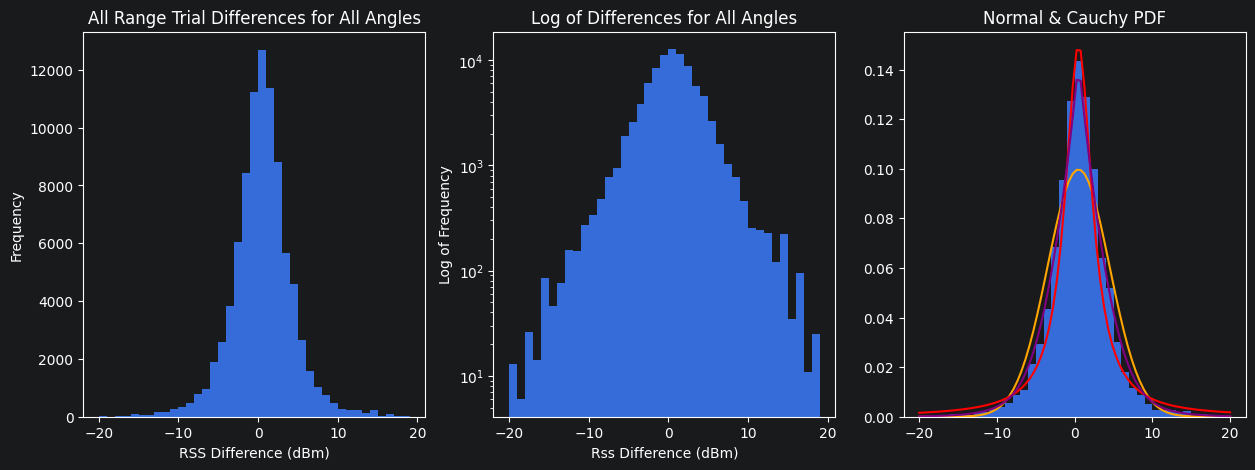

In [4]:
diffs_0 = combined_rss_at_gamma_analysis(range_logs, 1)
x_axis = np.linspace(-20, 20, 1000)

plt.show()

#### -15 to 15 Degrees

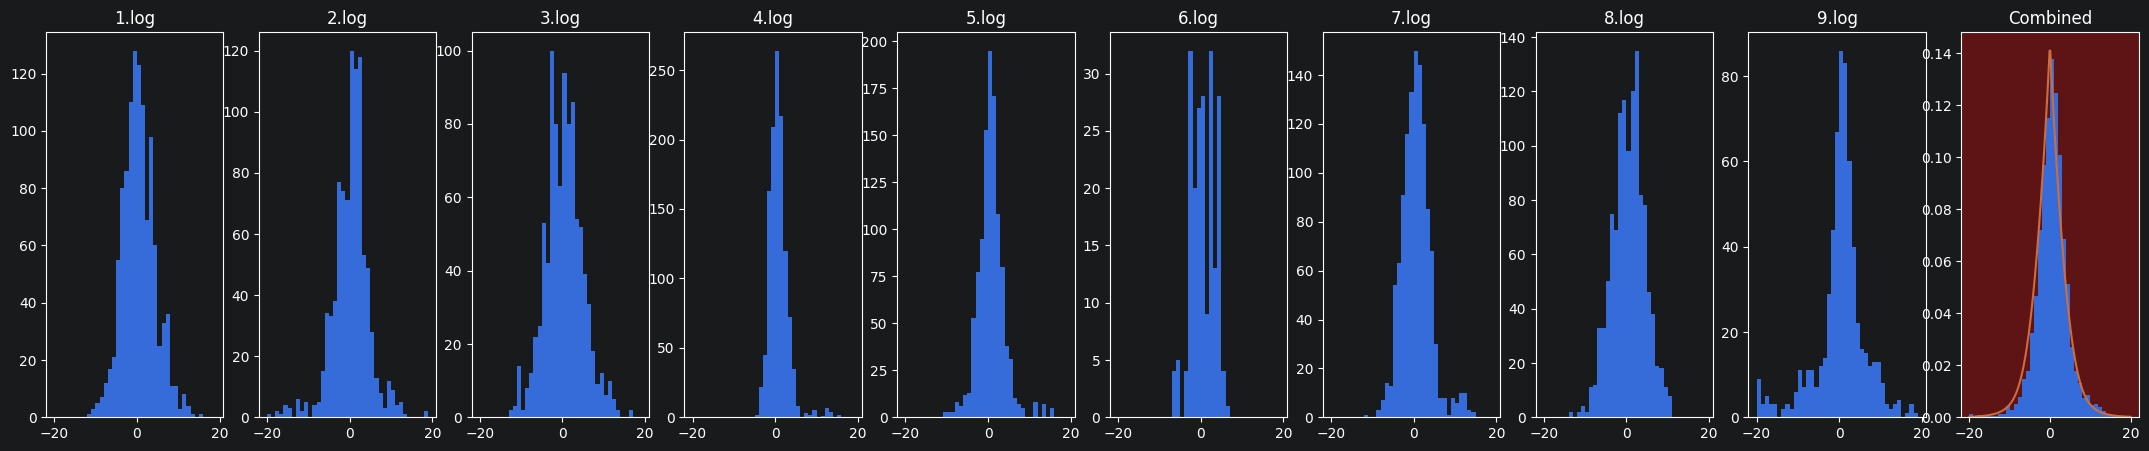

#### 15 to 45 Degrees

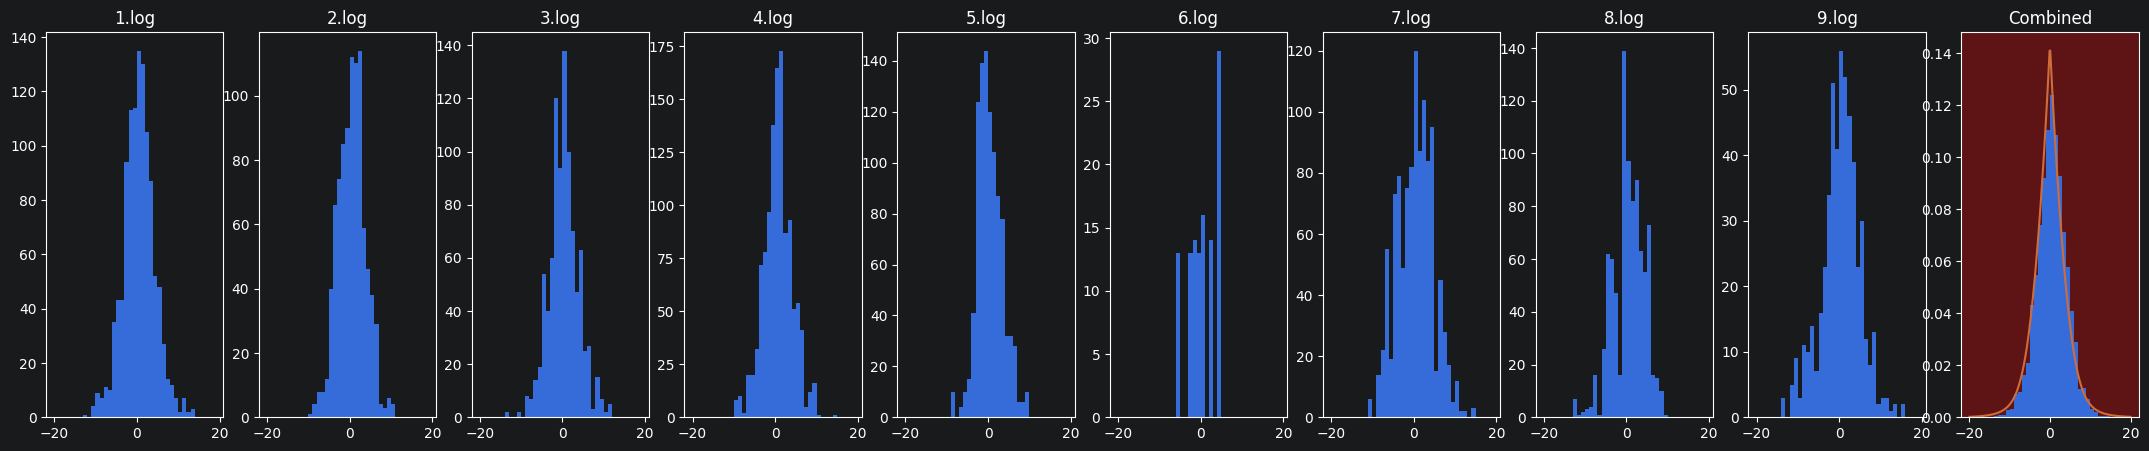

#### 45 to 75 Degrees

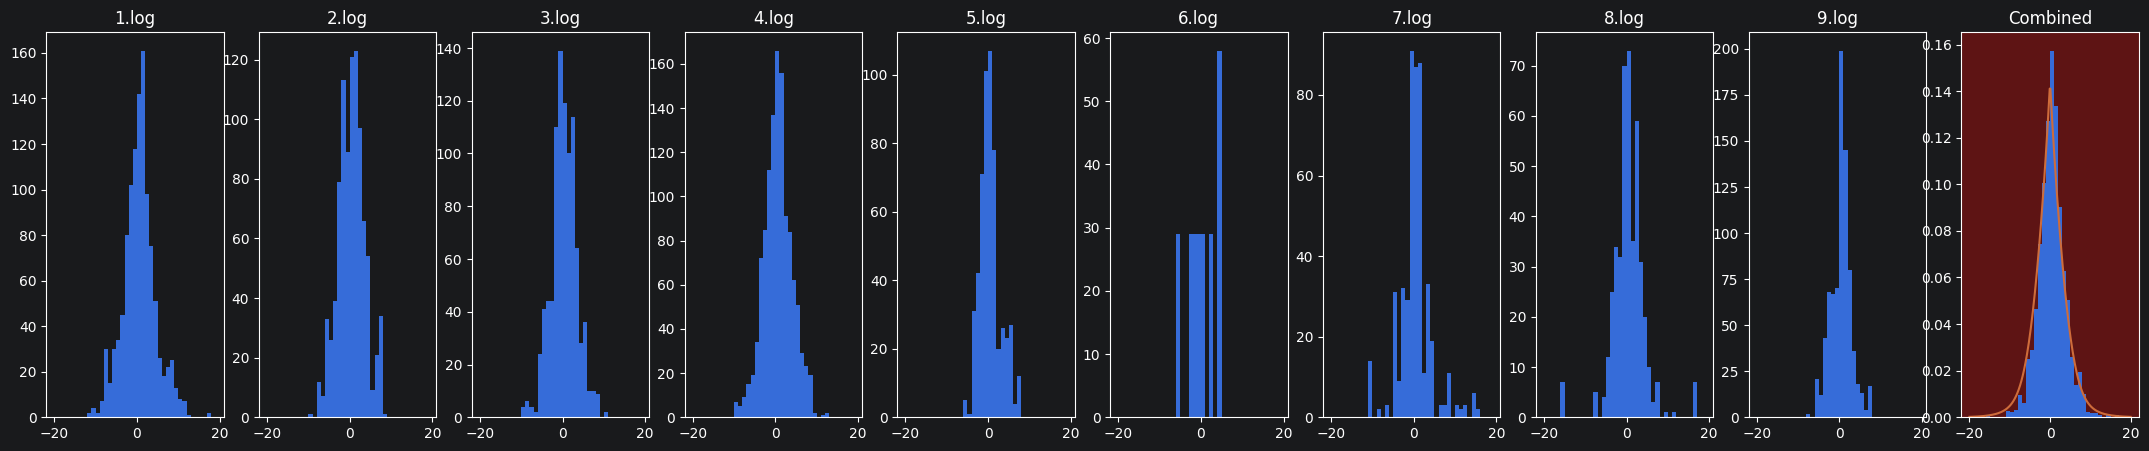

#### 75 to 105 Degrees

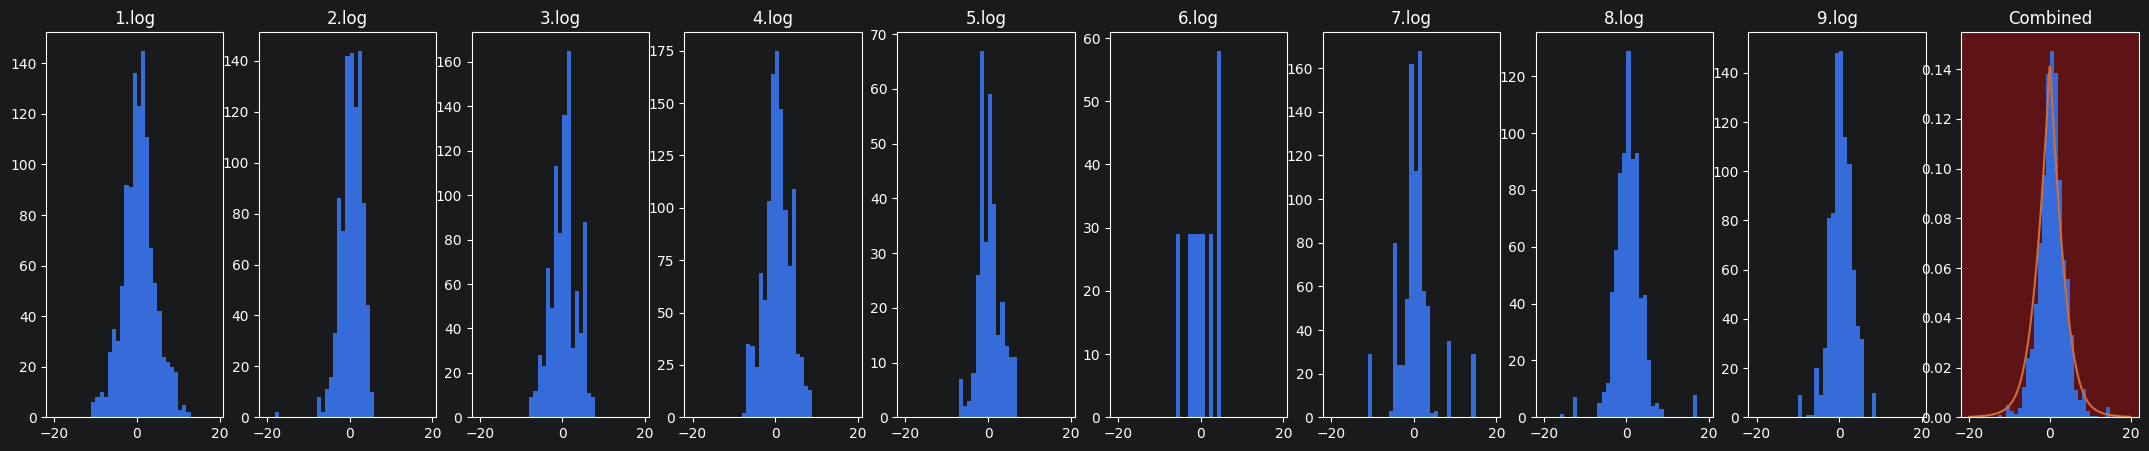

#### 105 to 135 Degrees

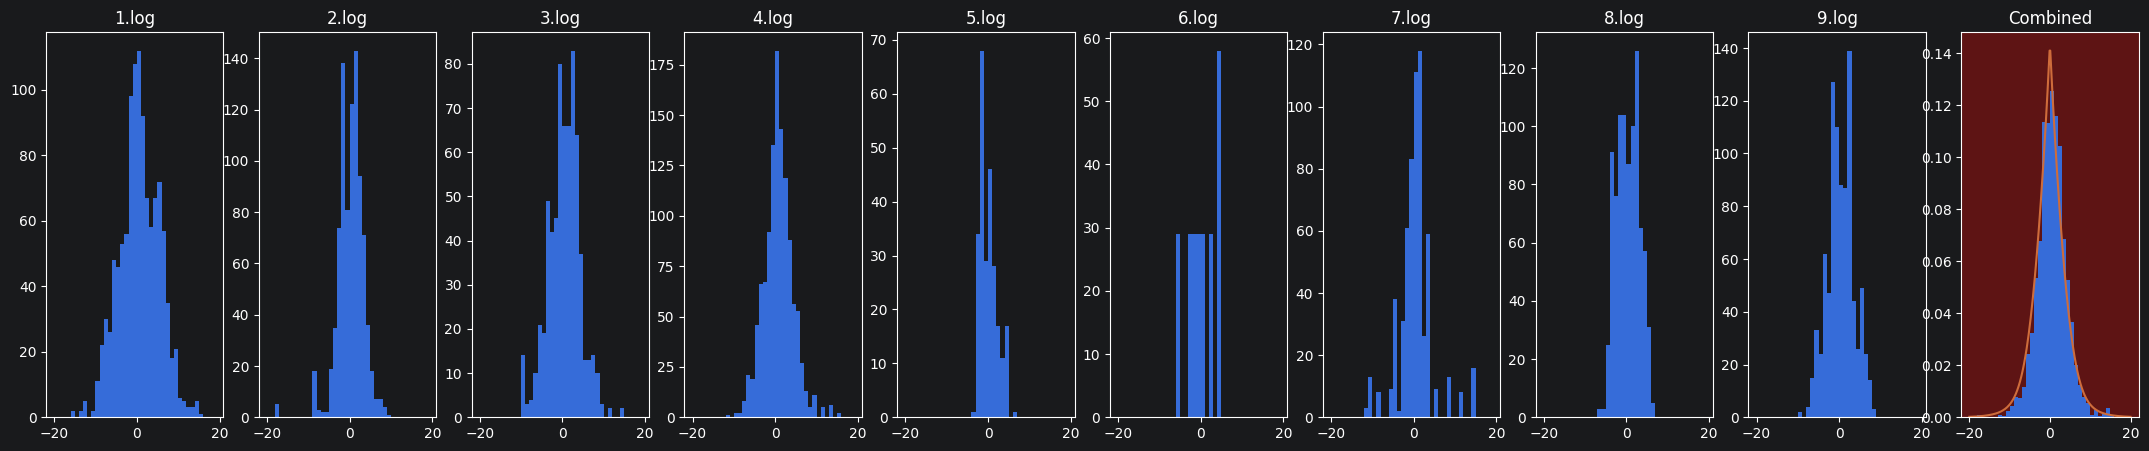

#### 135 to 165 Degrees

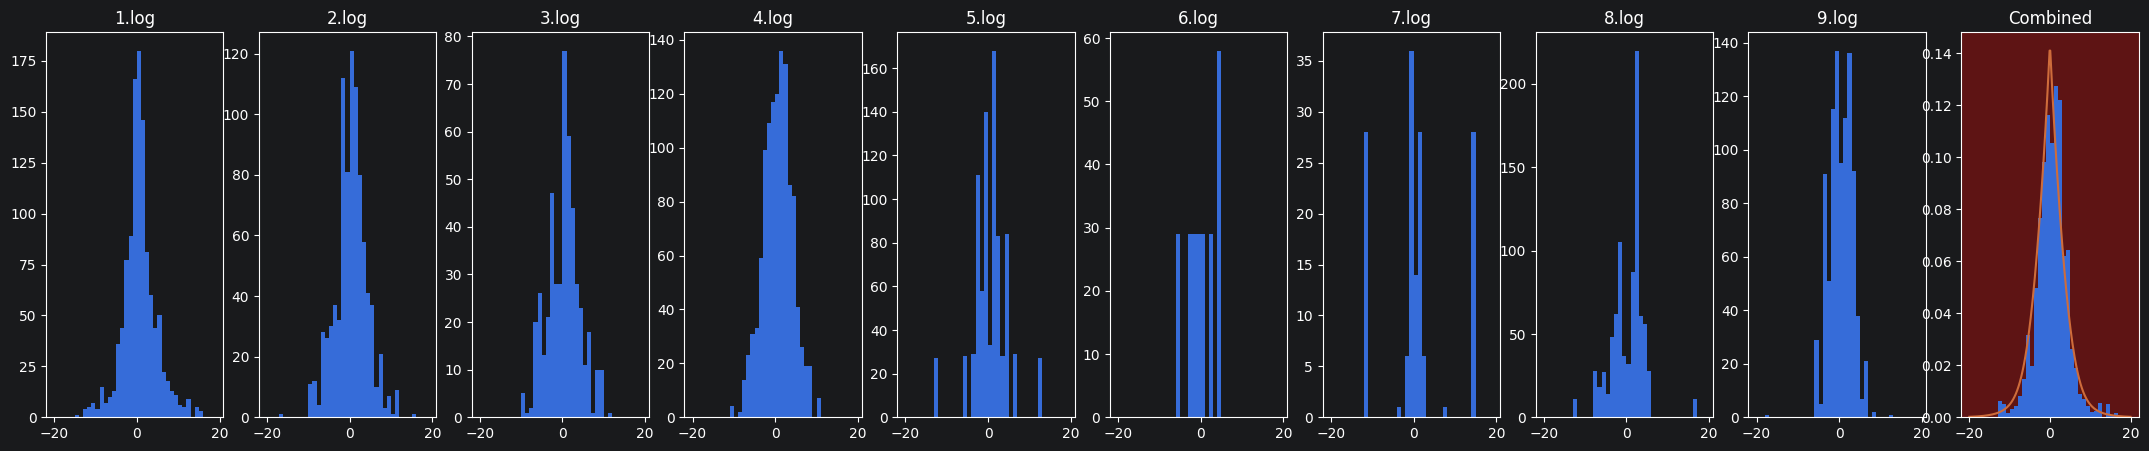

#### 165 to 195 Degrees

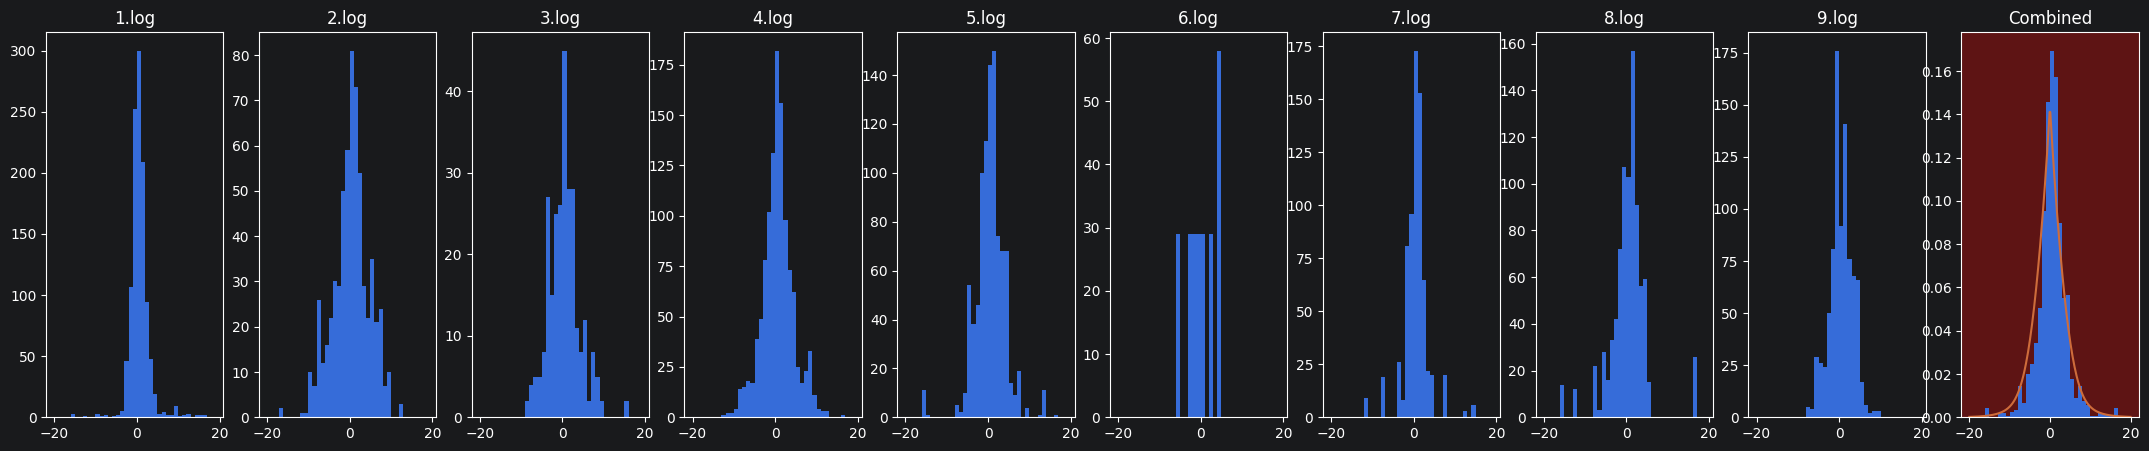

#### 195 to 225 Degrees

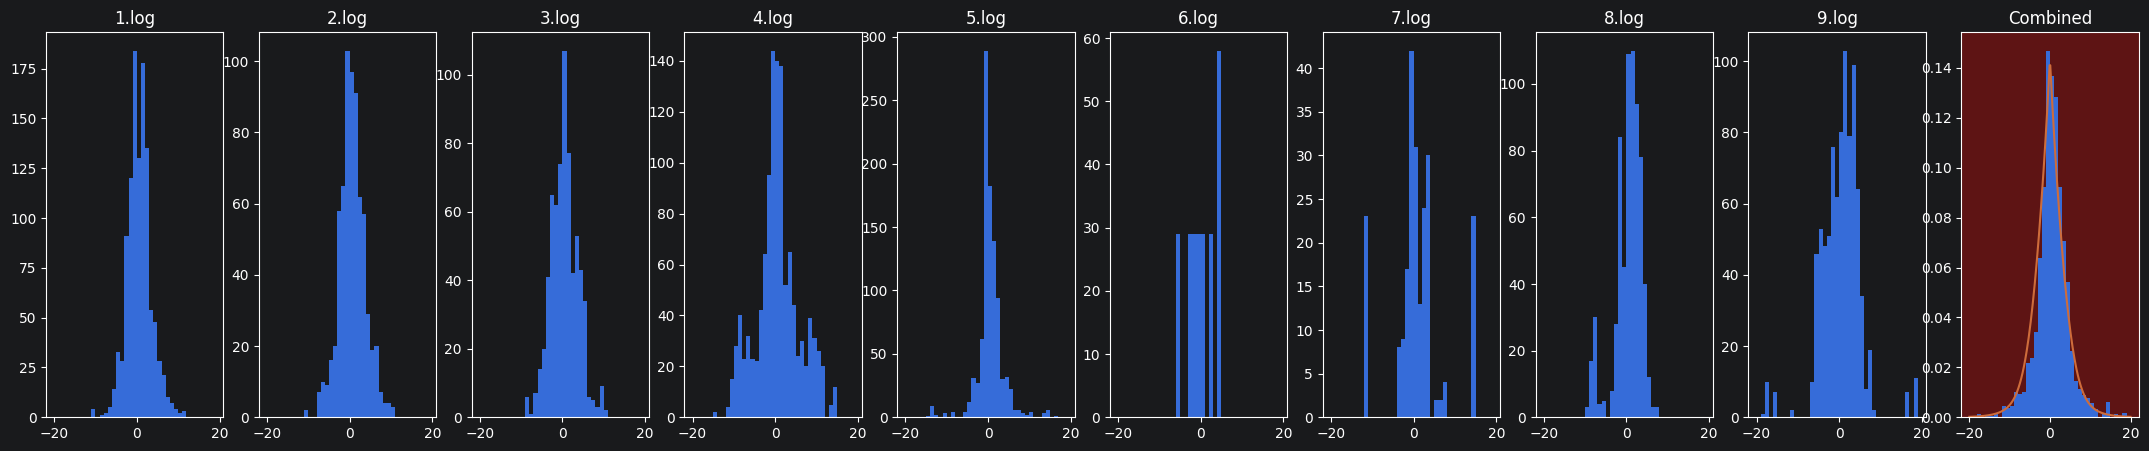

#### 225 to 255 Degrees

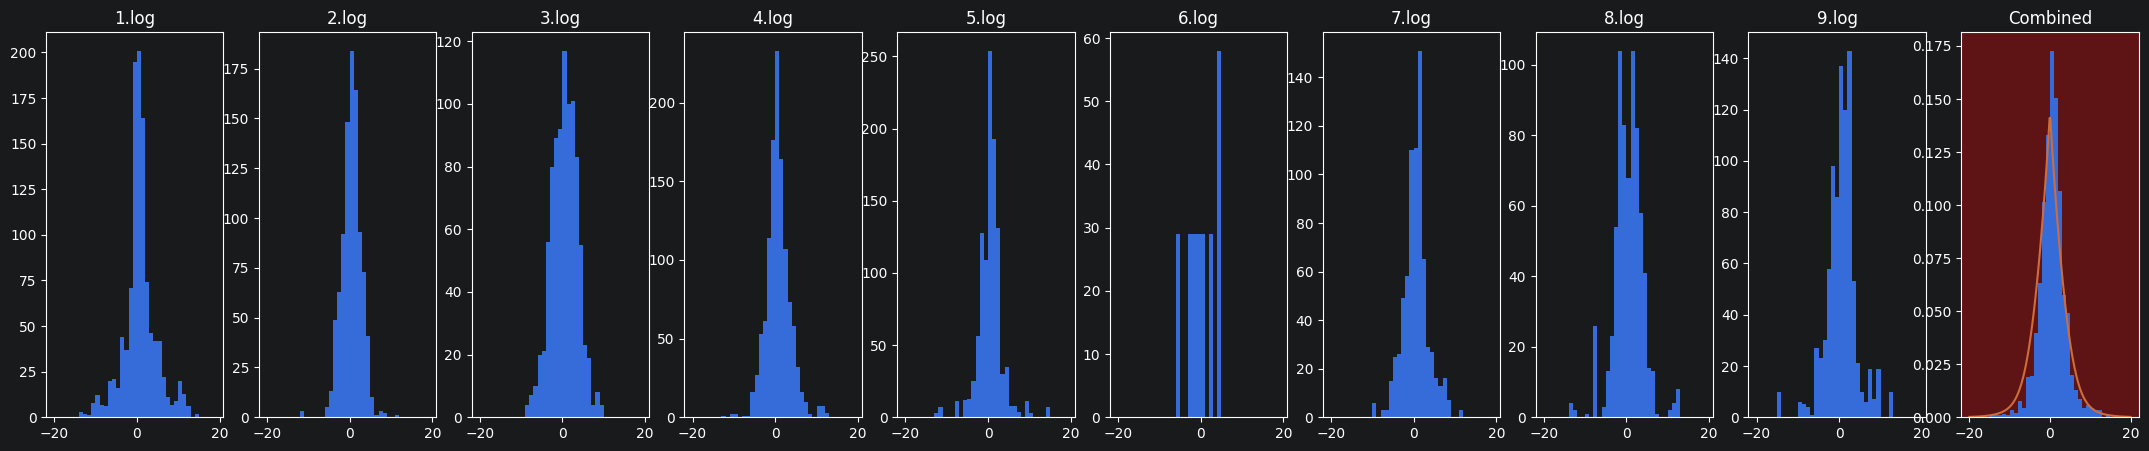

#### 255 to 285 Degrees

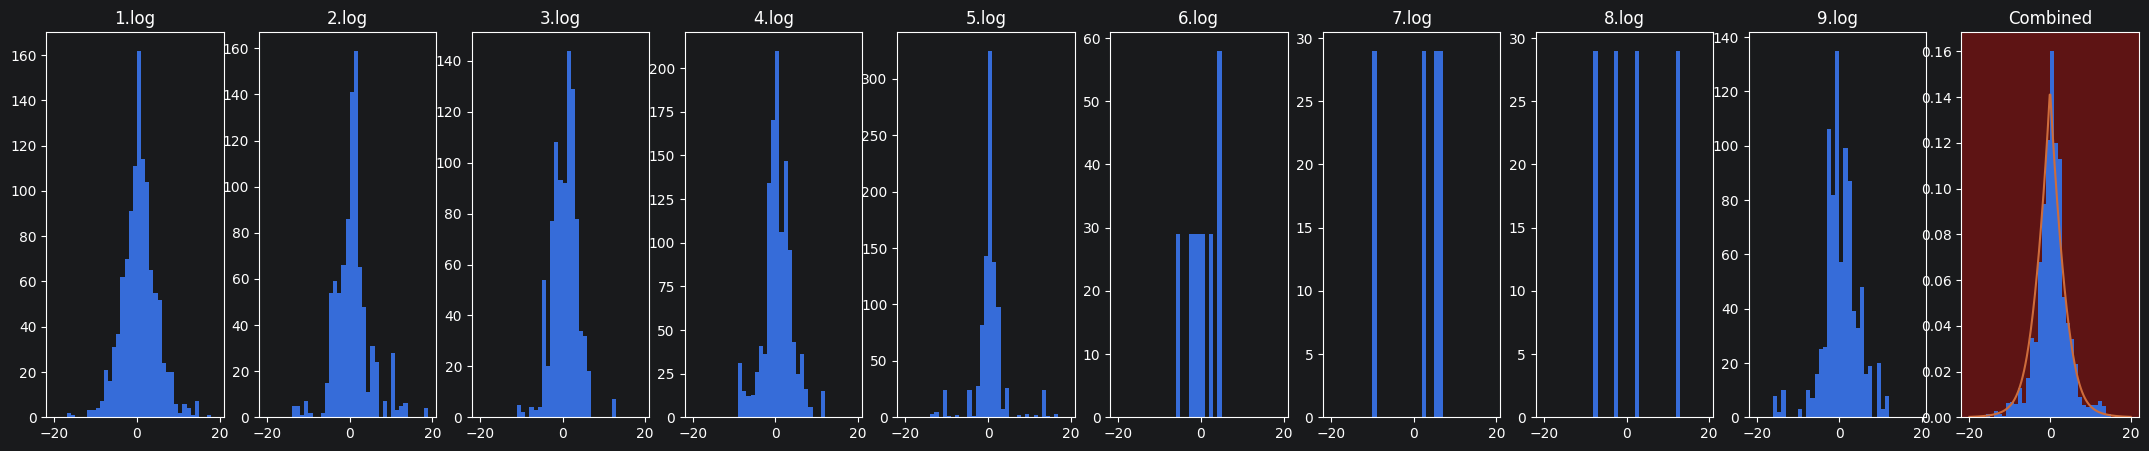

#### 285 to 315 Degrees

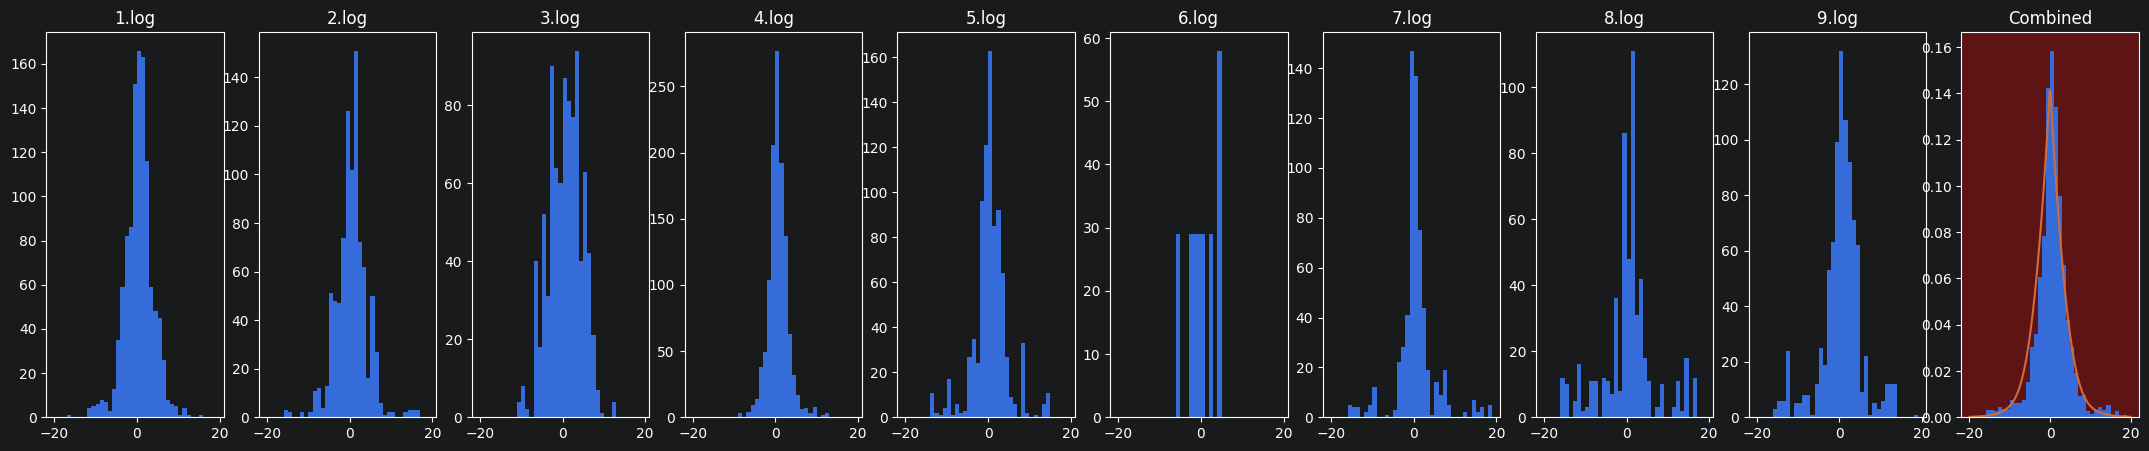

#### 315 to 345 Degrees

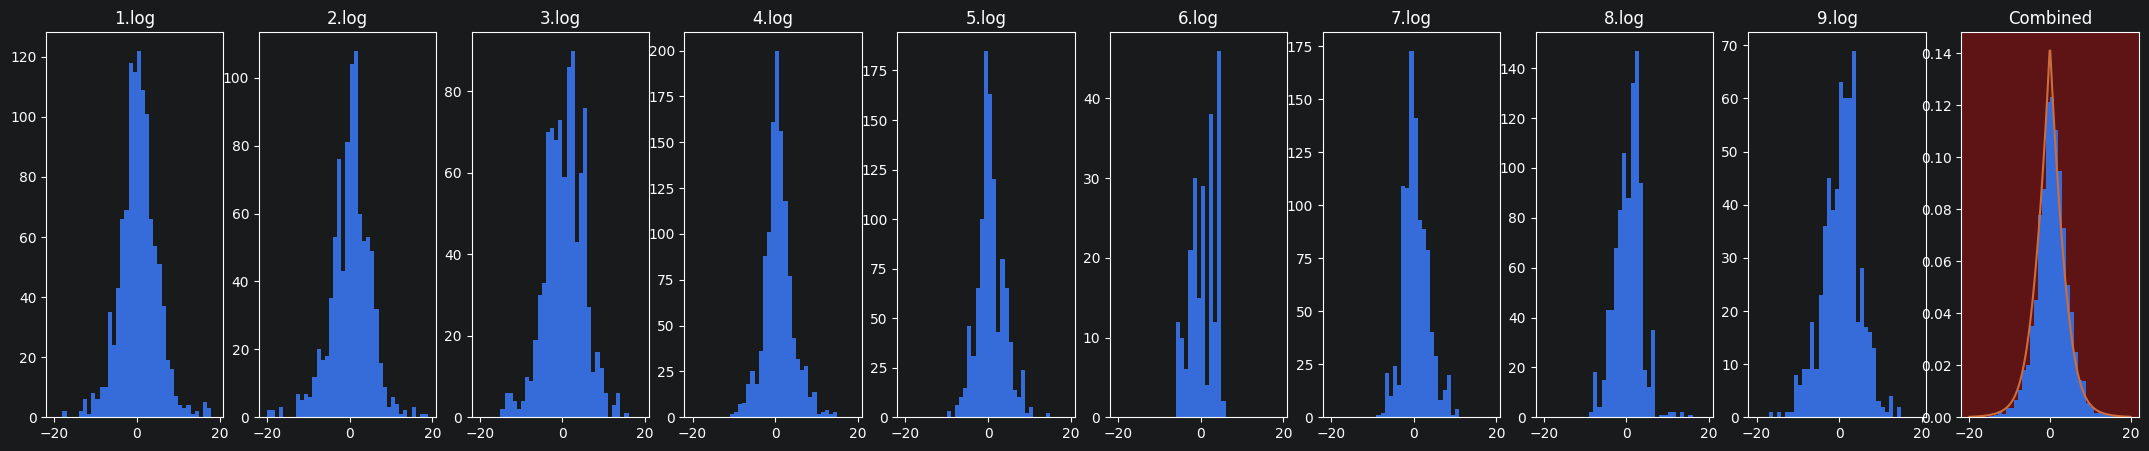

In [5]:
range_trial_rss_diffs_in_blocks(range_logs)

### Two Packet Differences

This would be applicable if a sample is taken over 4 seconds

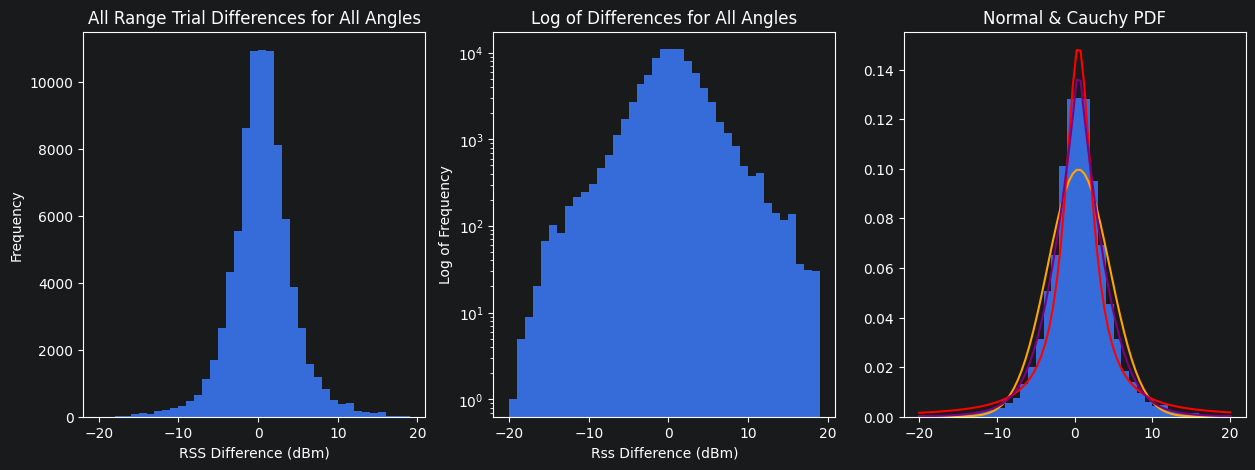

In [6]:
diffs_2 = combined_rss_at_gamma_analysis(range_logs, 2)

#### -15 to 15 Degrees

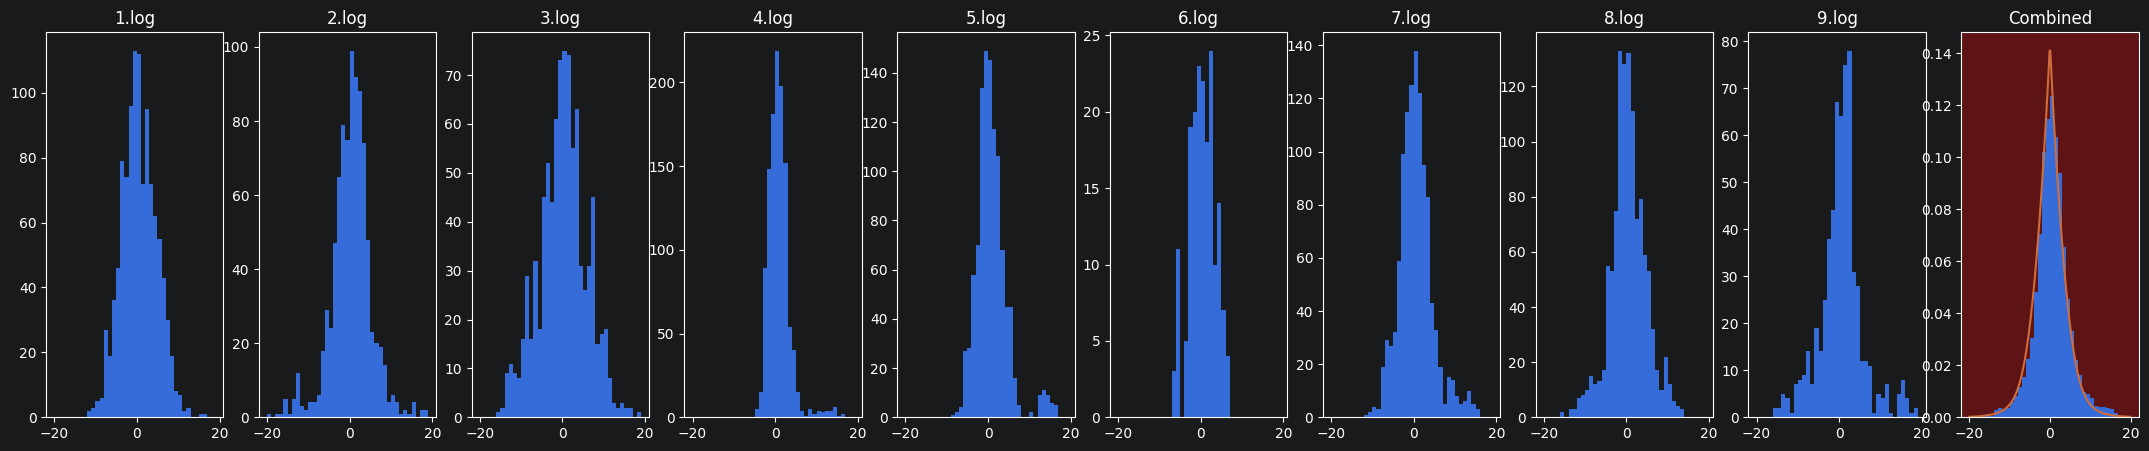

#### 15 to 45 Degrees

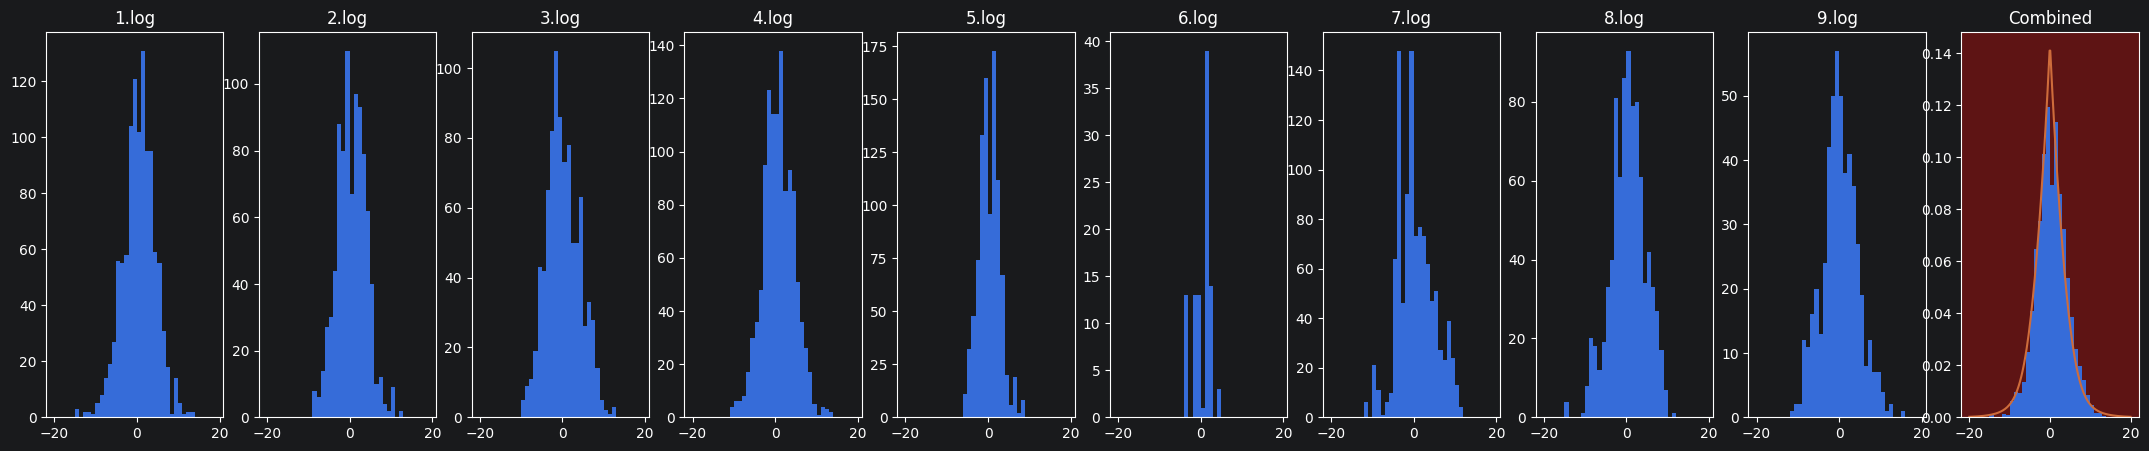

#### 45 to 75 Degrees

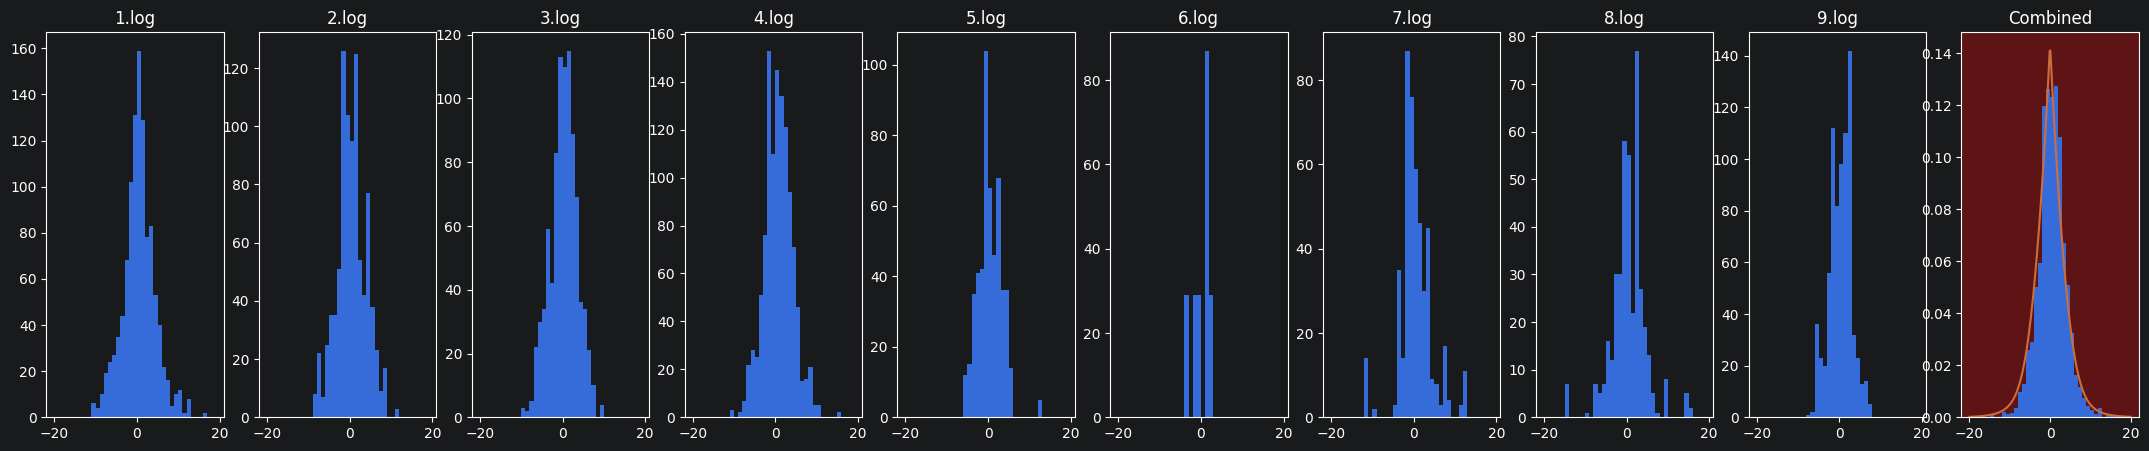

#### 75 to 105 Degrees

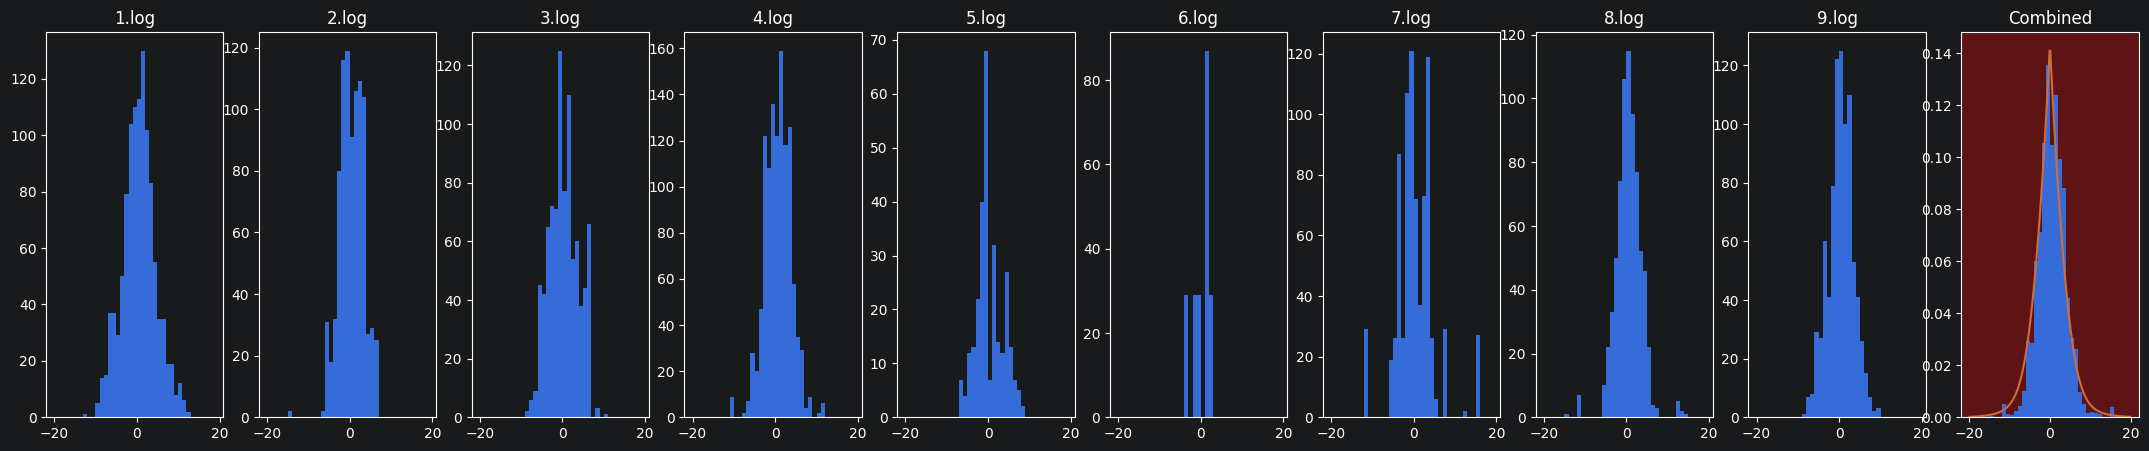

#### 105 to 135 Degrees

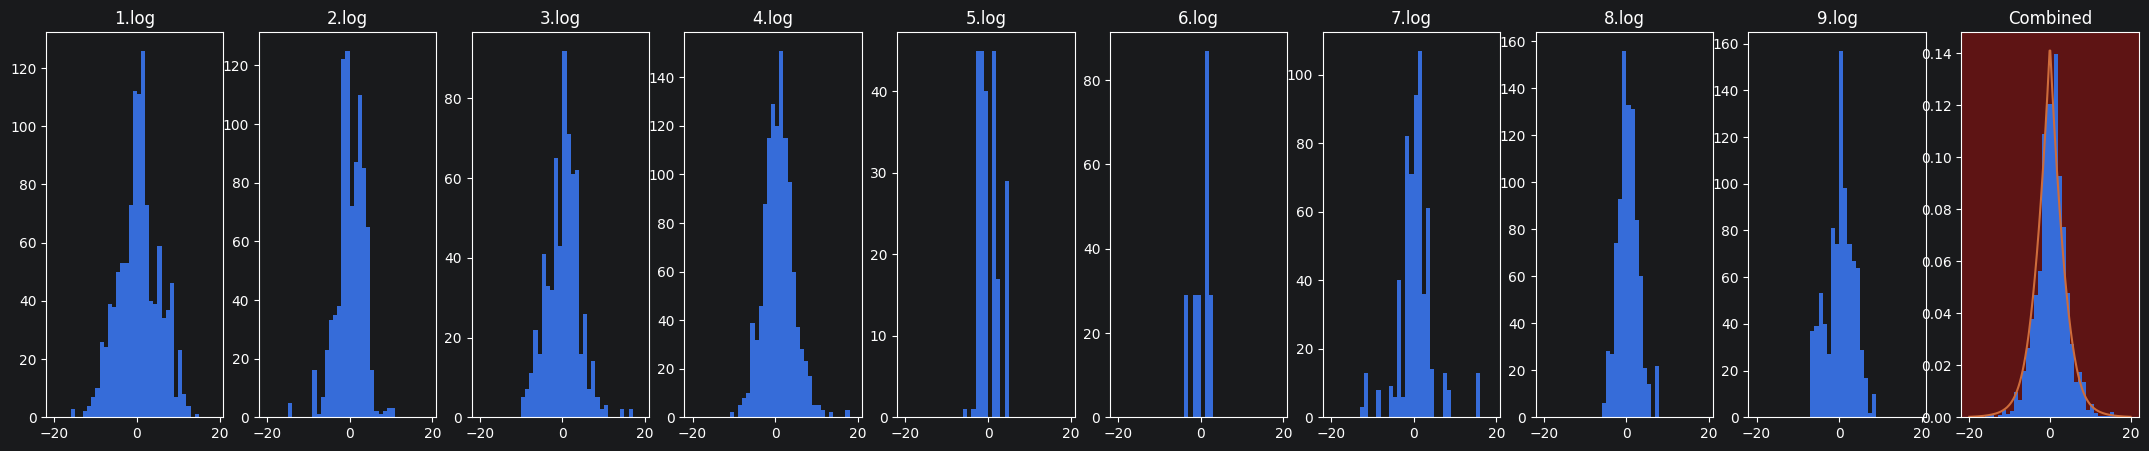

#### 135 to 165 Degrees

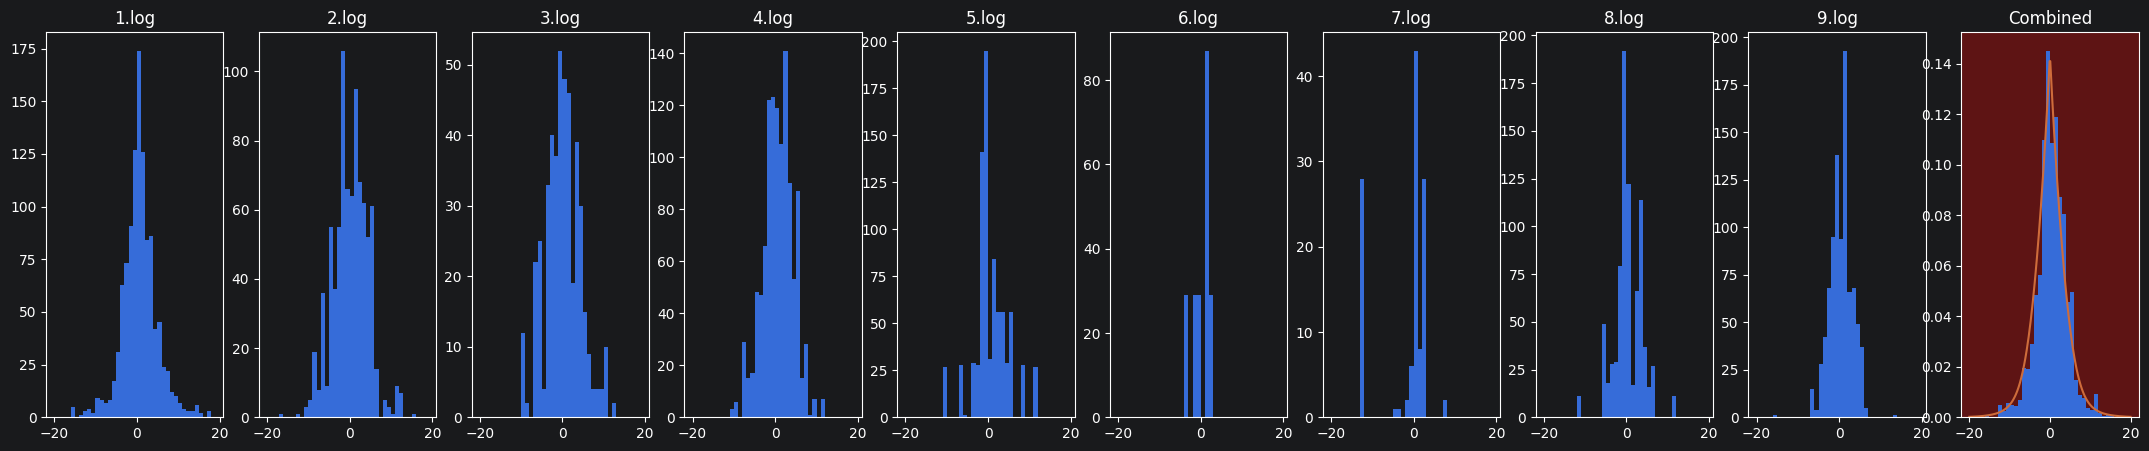

#### 165 to 195 Degrees

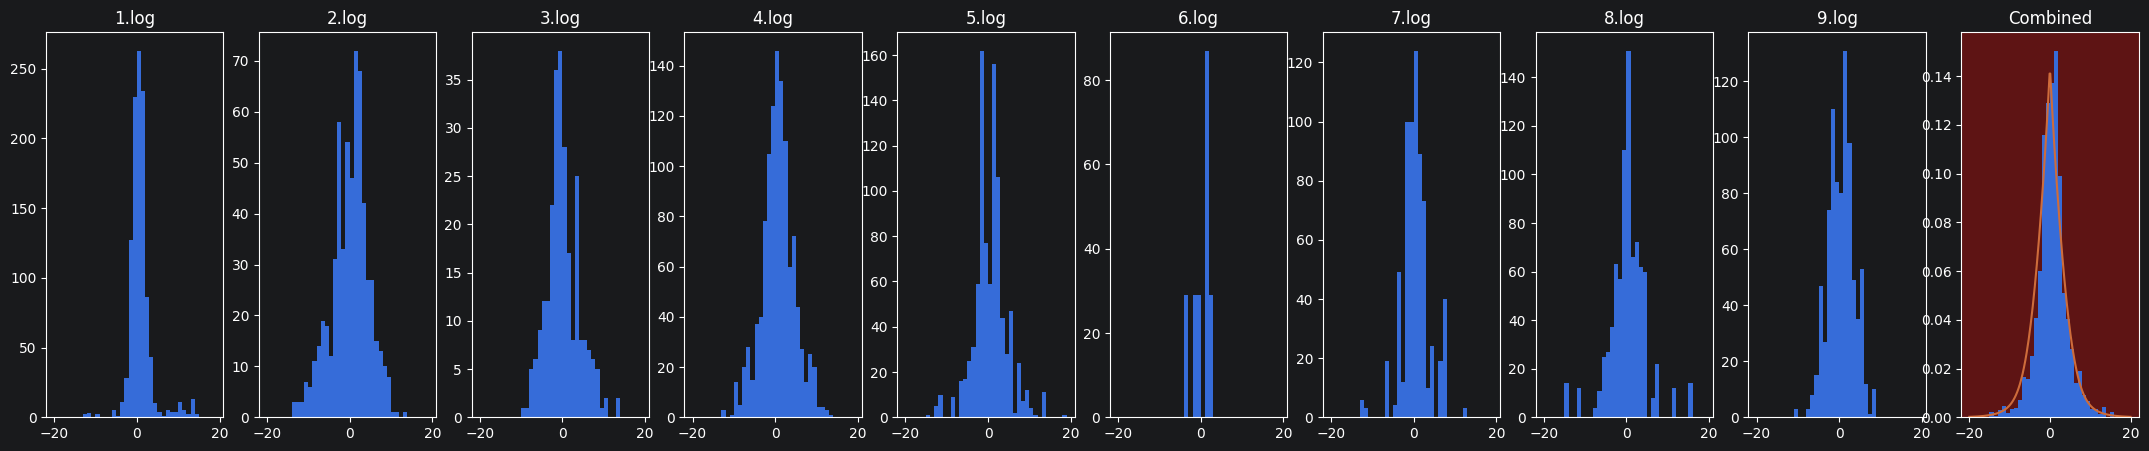

#### 195 to 225 Degrees

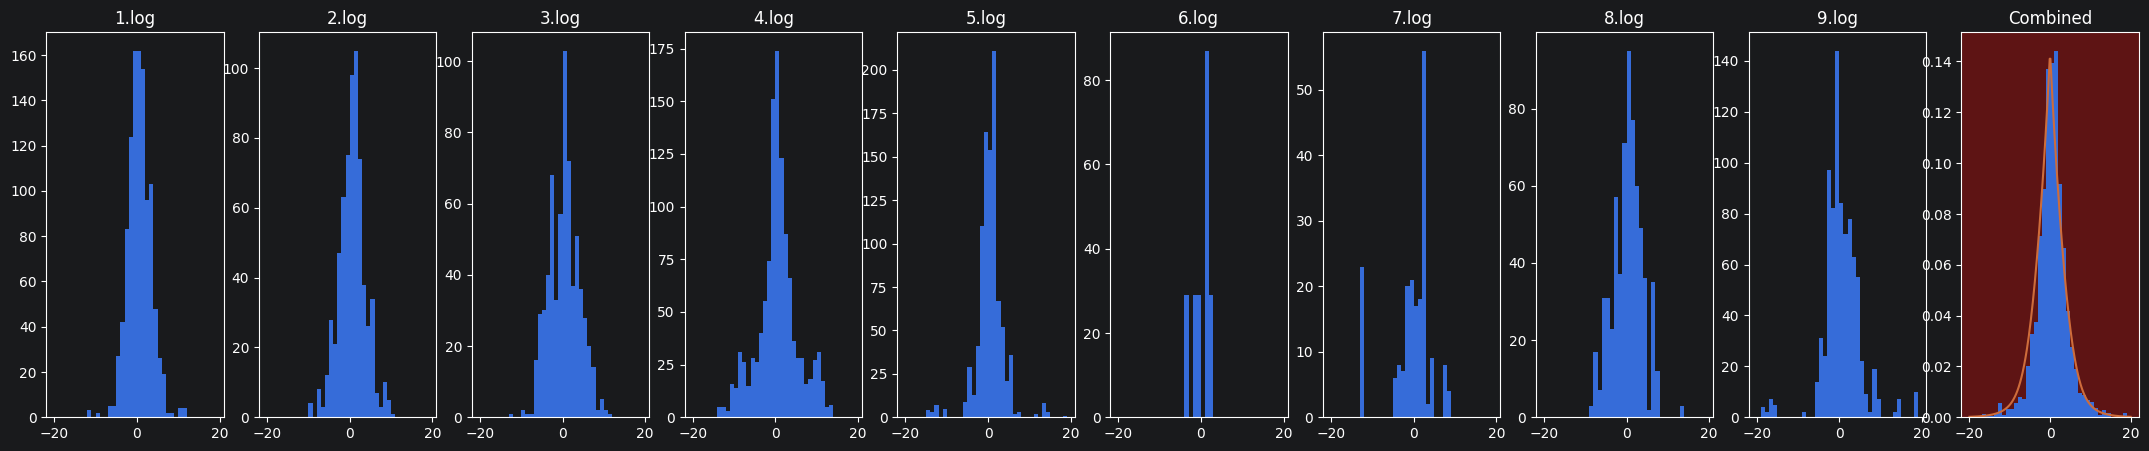

#### 225 to 255 Degrees

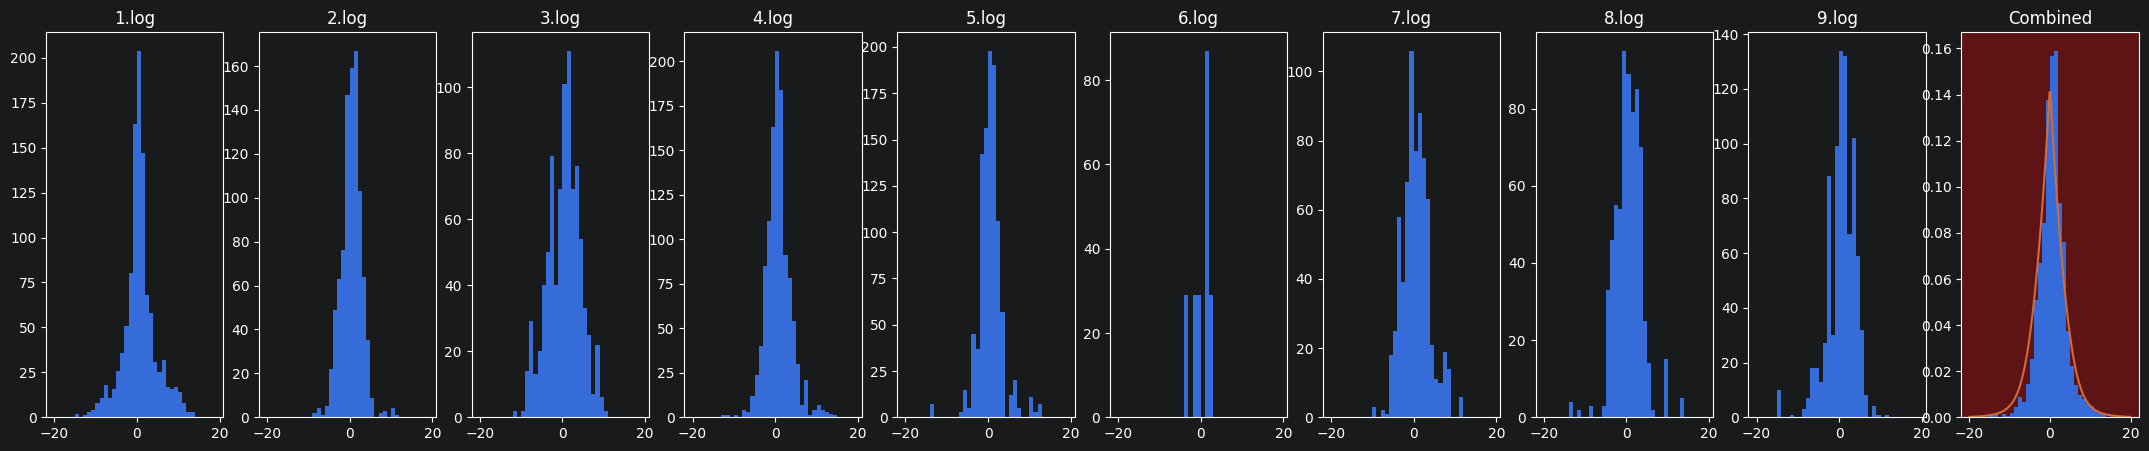

#### 255 to 285 Degrees

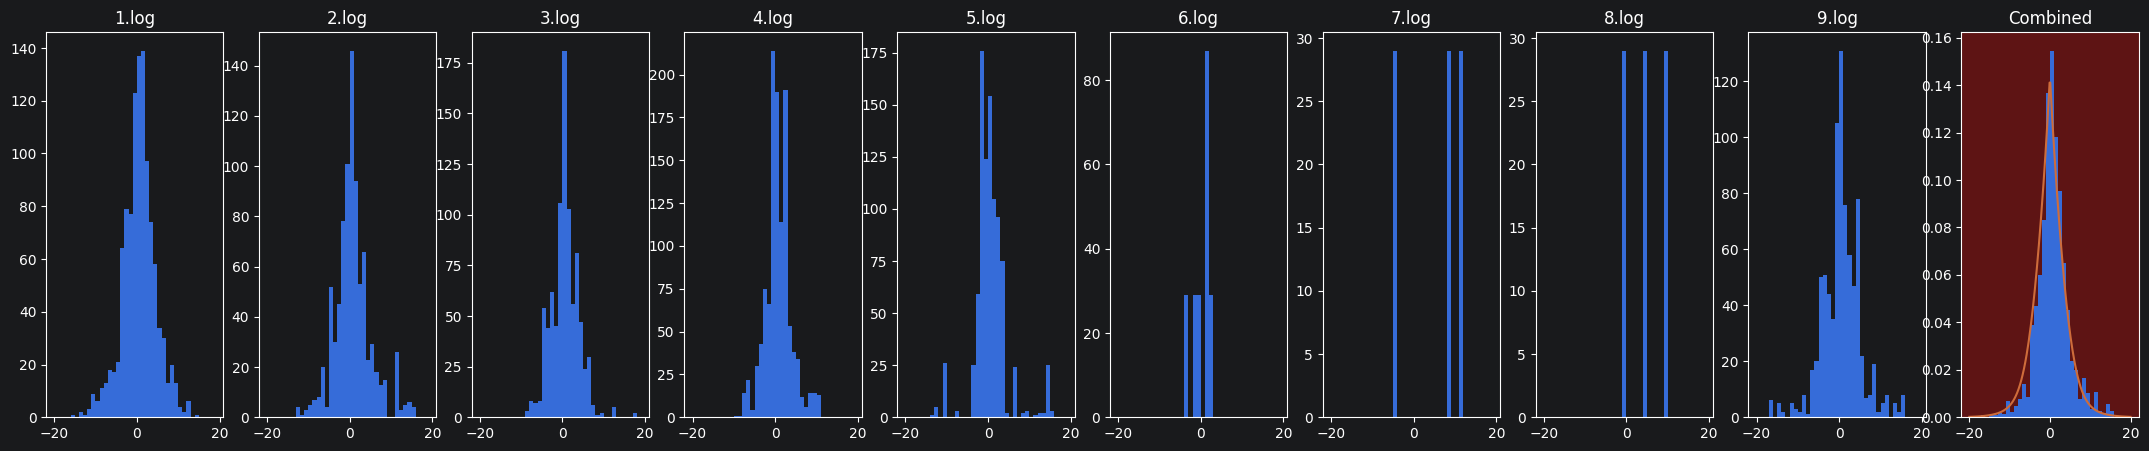

#### 285 to 315 Degrees

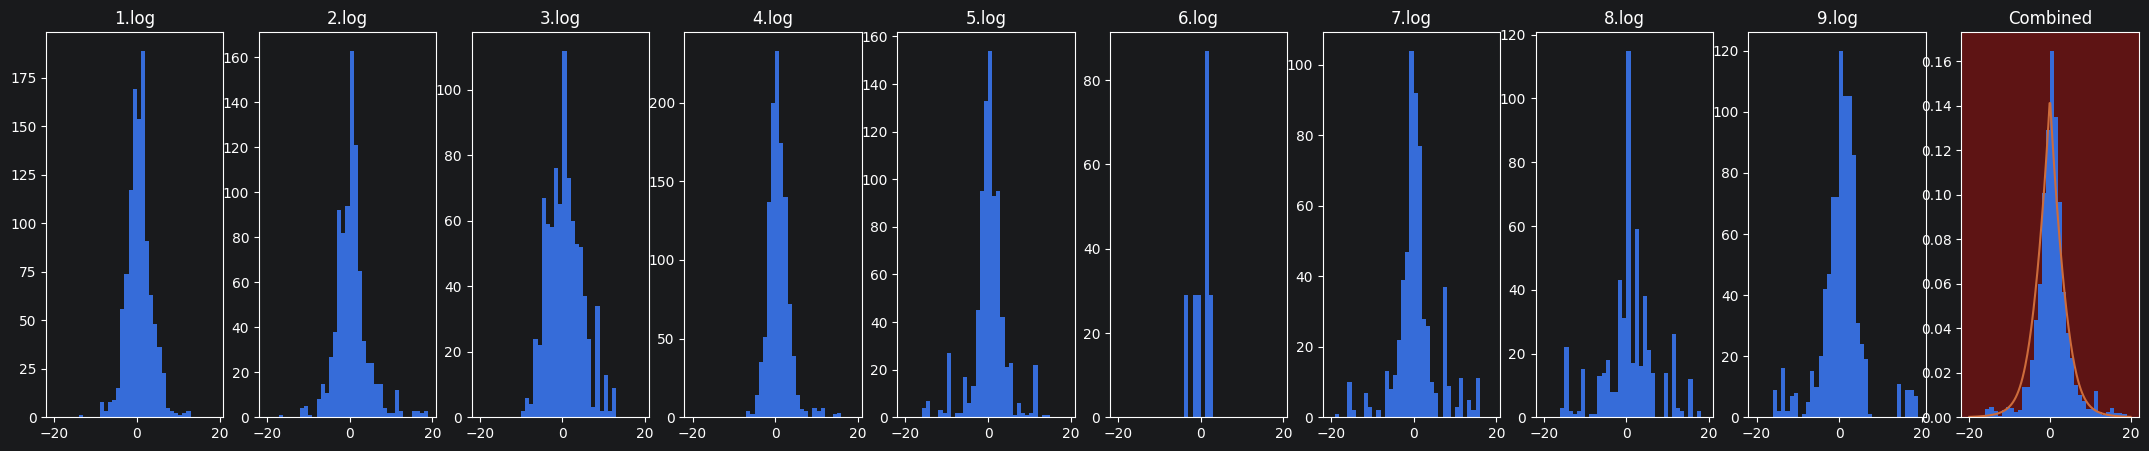

#### 315 to 345 Degrees

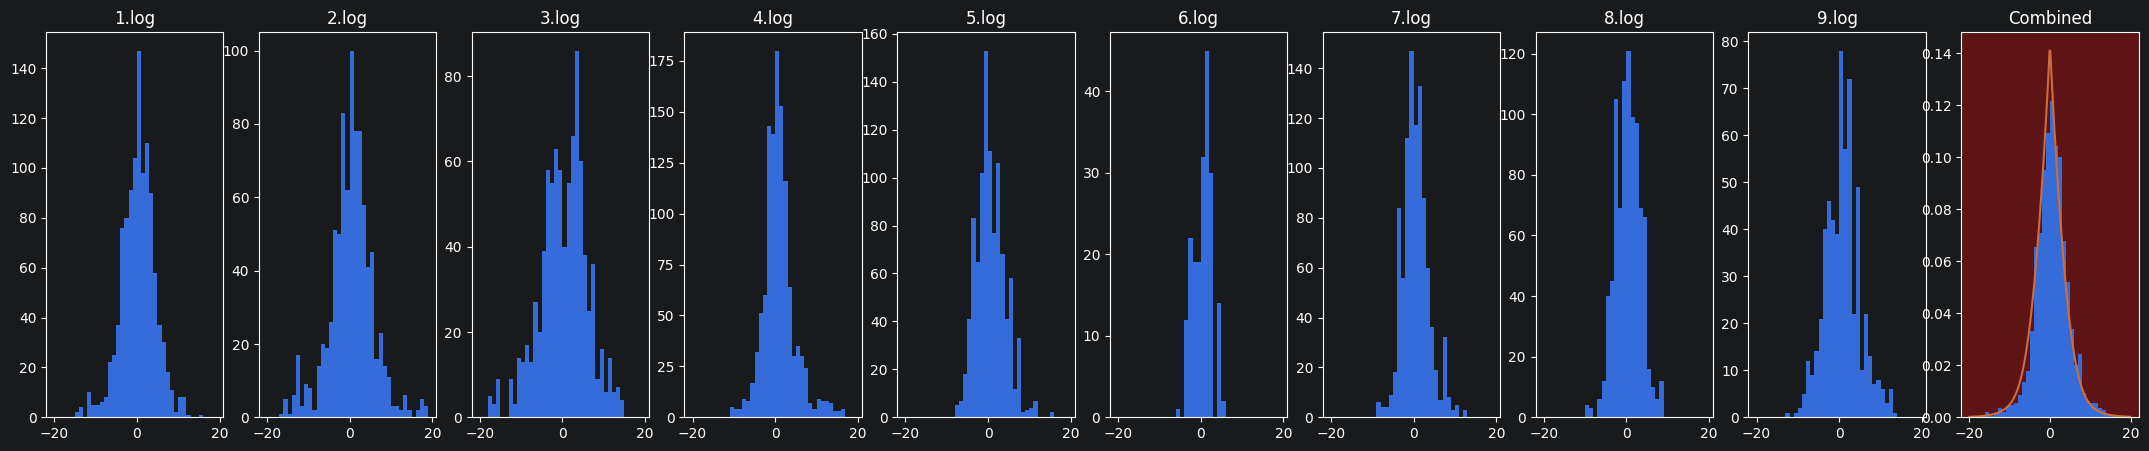

In [7]:
range_trial_rss_diffs_in_blocks(range_logs, 2)

### Five Packet Differences

The difference is taken between the current packet and the packet at the same gamma in five transmitter-rotations' time (approximately 10 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

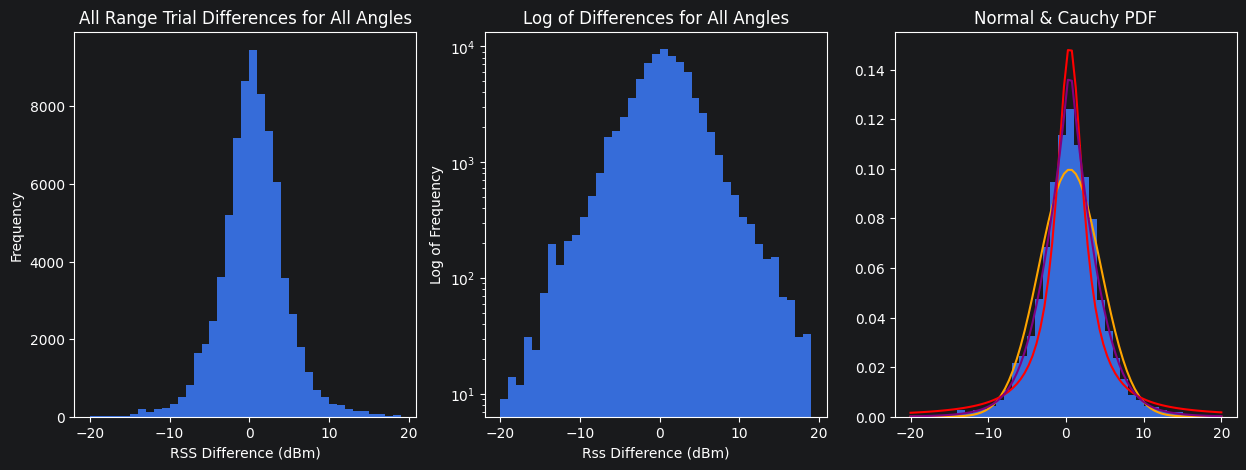

In [8]:
diffs_5 = combined_rss_at_gamma_analysis(range_logs, 5)

#### -15 to 15 Degrees

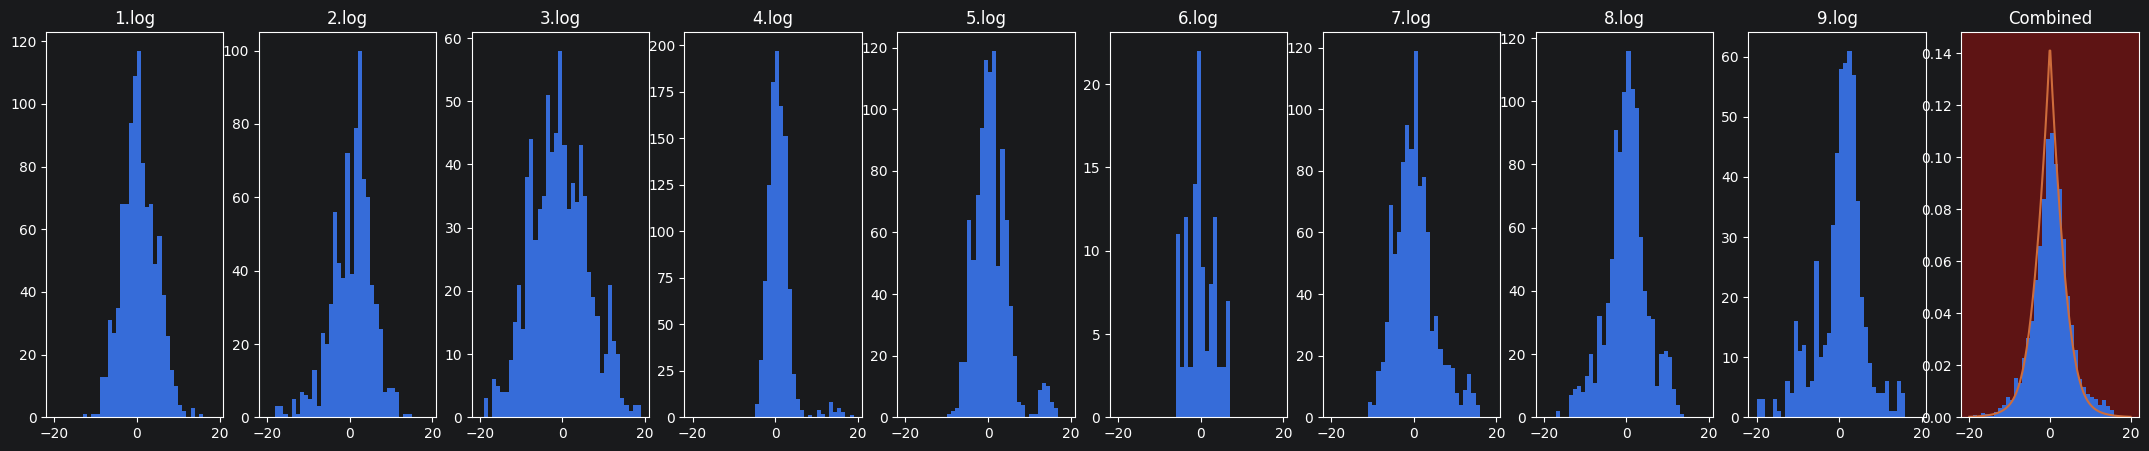

#### 15 to 45 Degrees

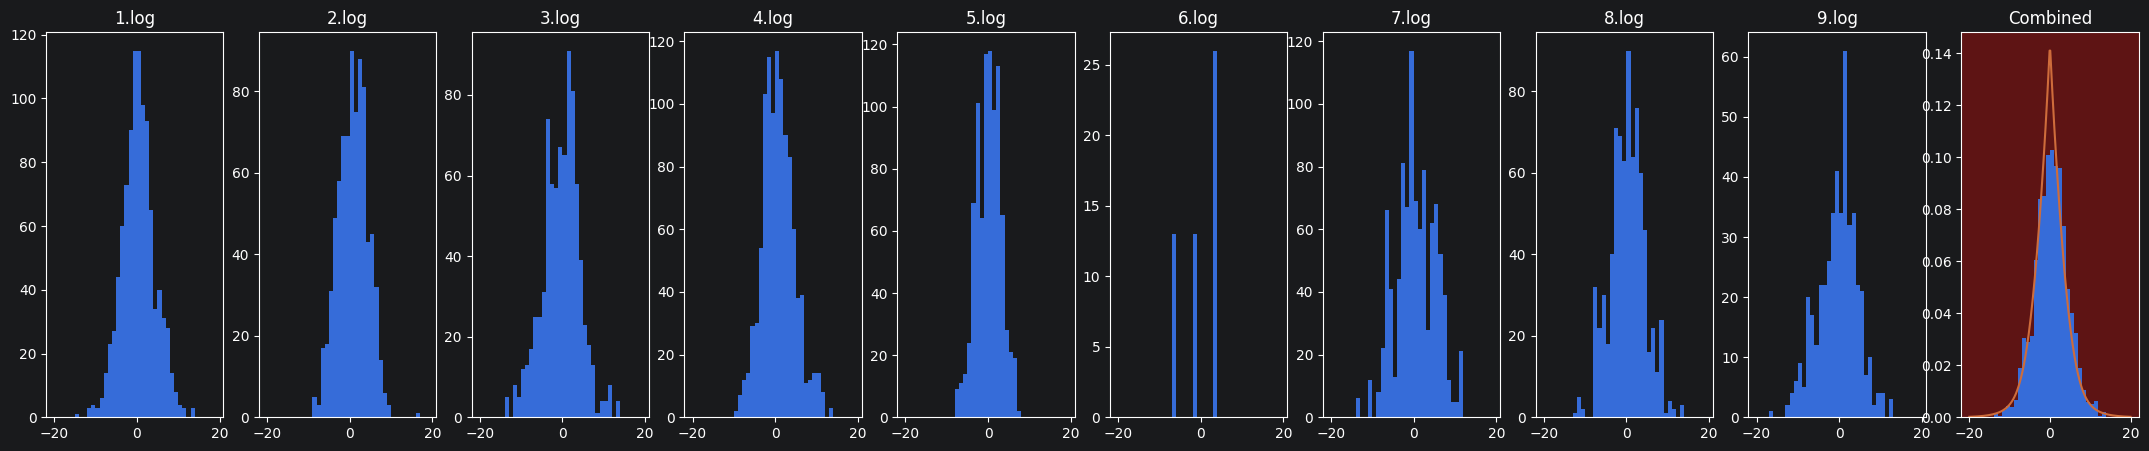

#### 45 to 75 Degrees

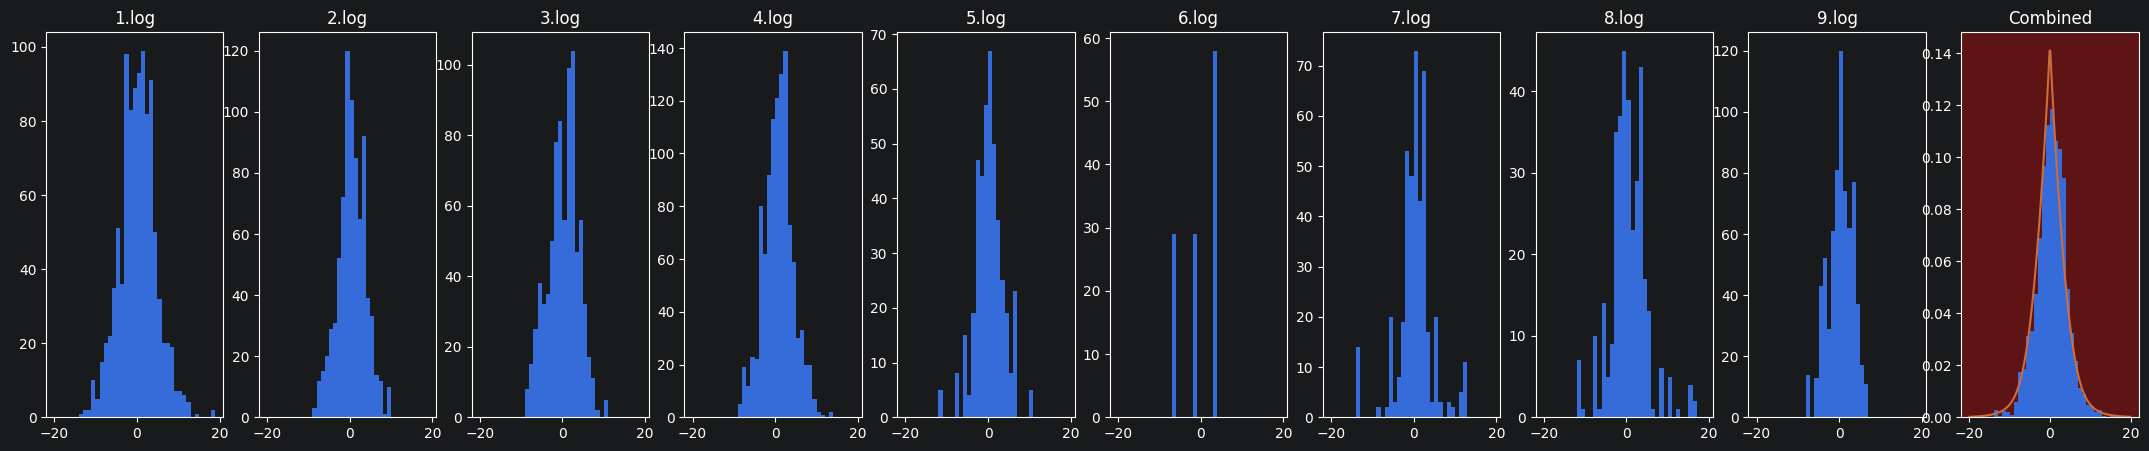

#### 75 to 105 Degrees

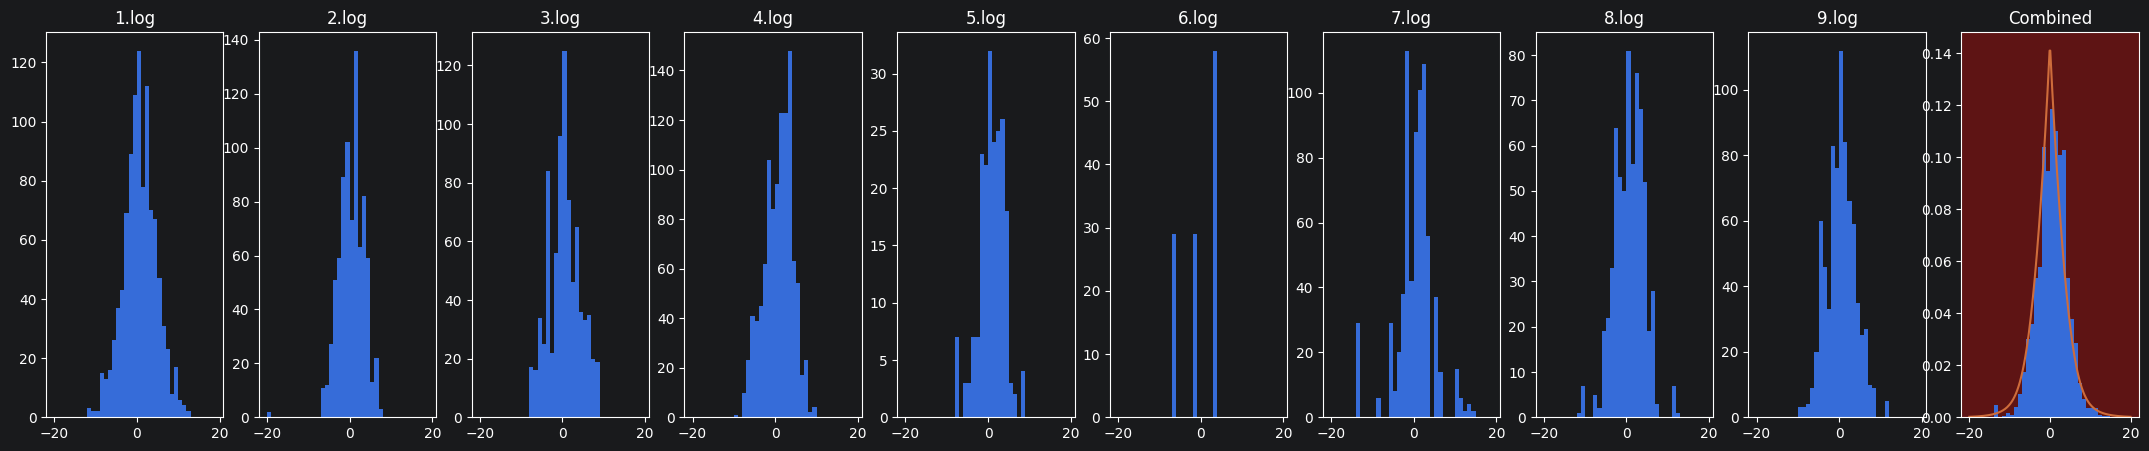

#### 105 to 135 Degrees

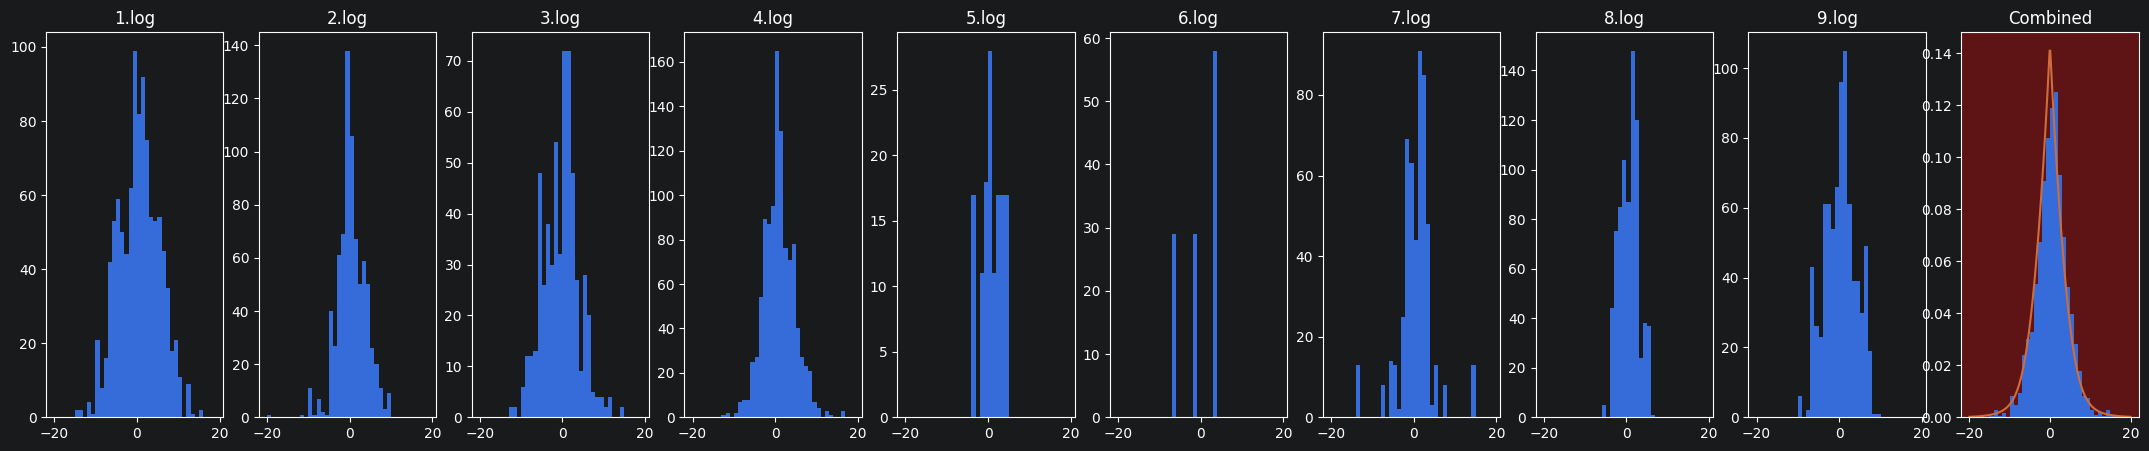

#### 135 to 165 Degrees

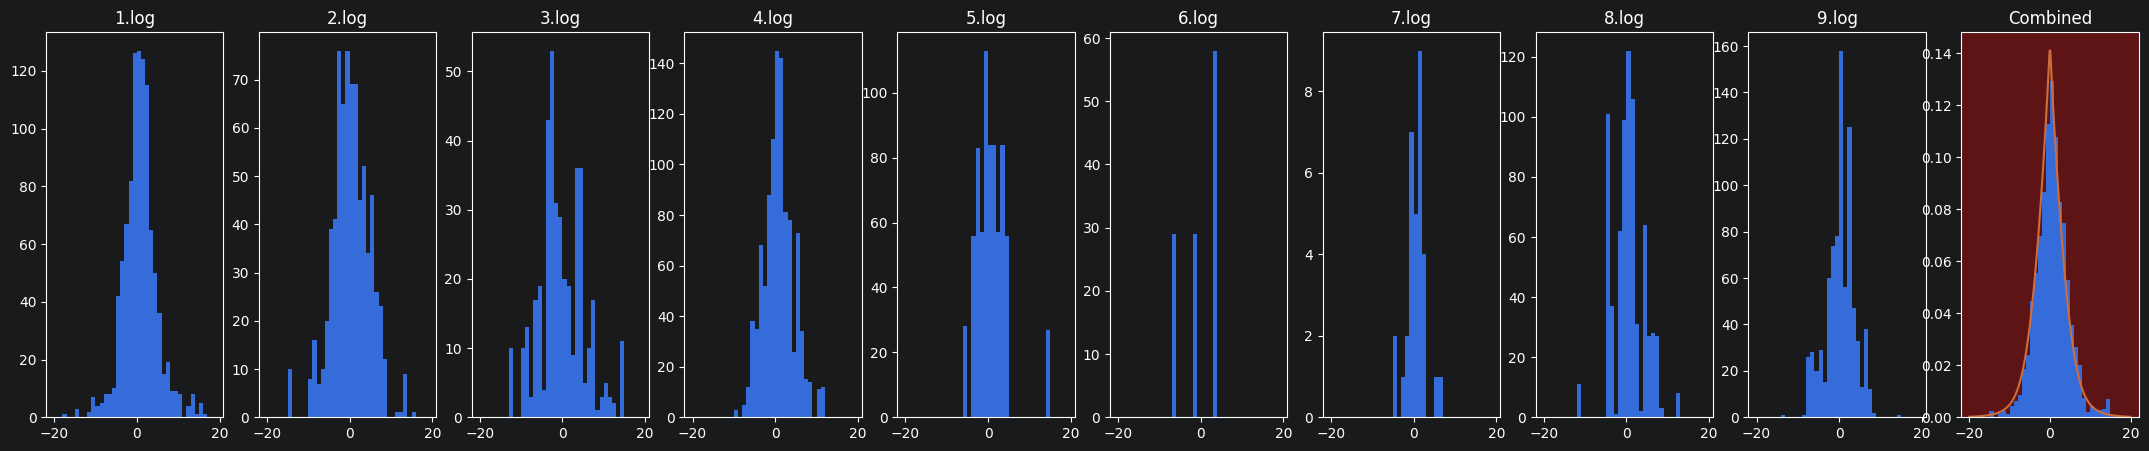

#### 165 to 195 Degrees

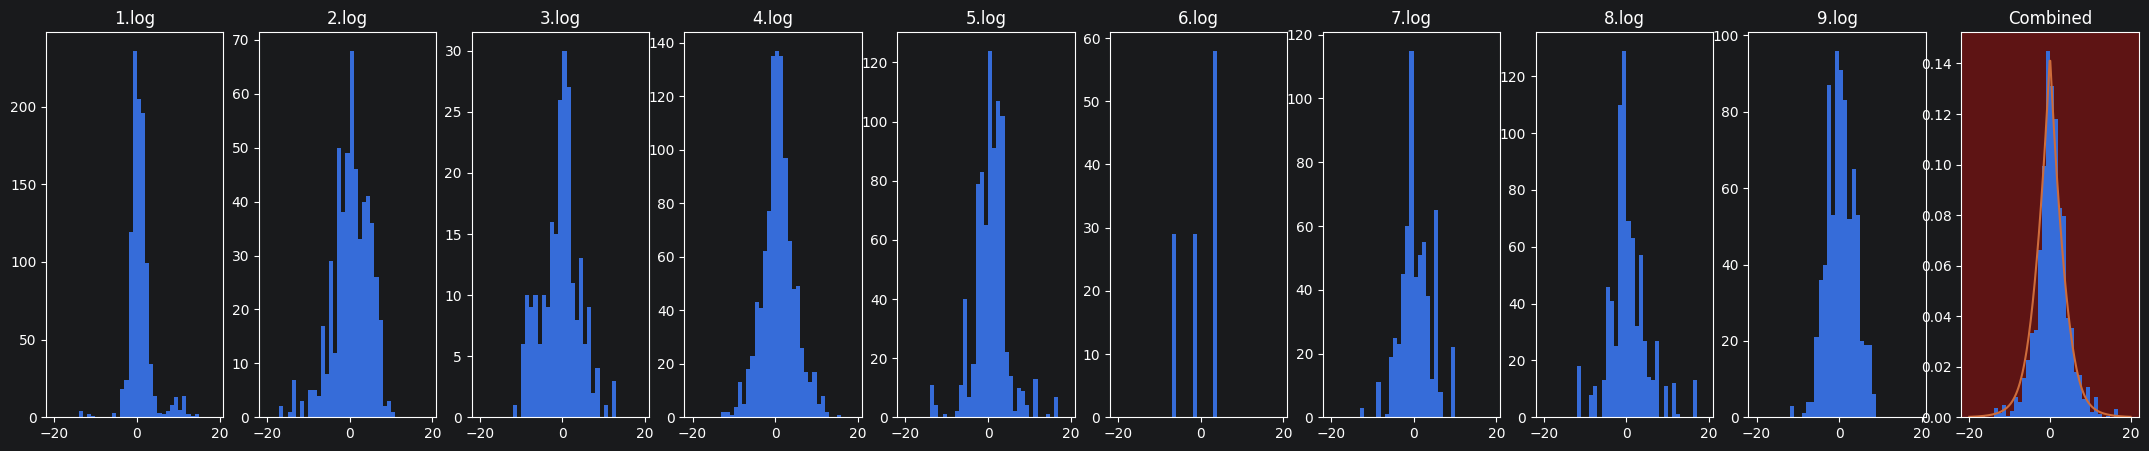

#### 195 to 225 Degrees

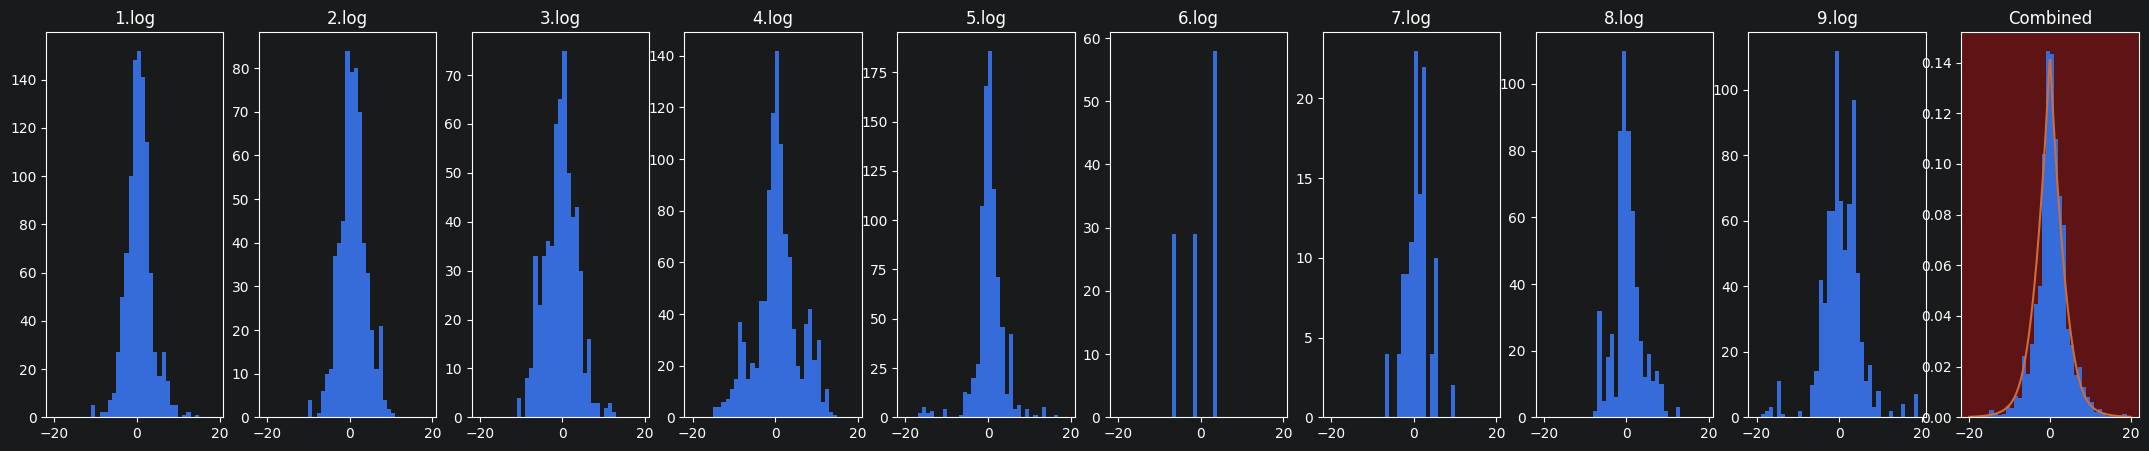

#### 225 to 255 Degrees

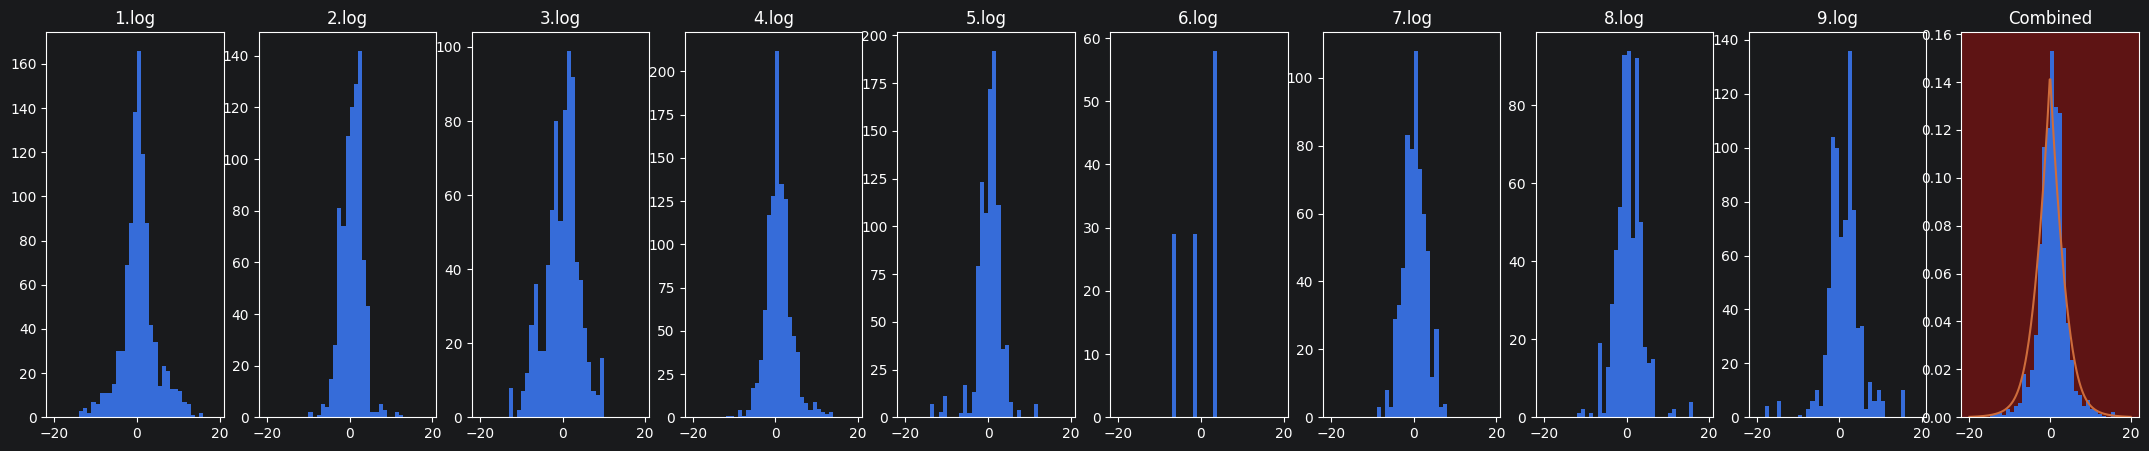

#### 255 to 285 Degrees

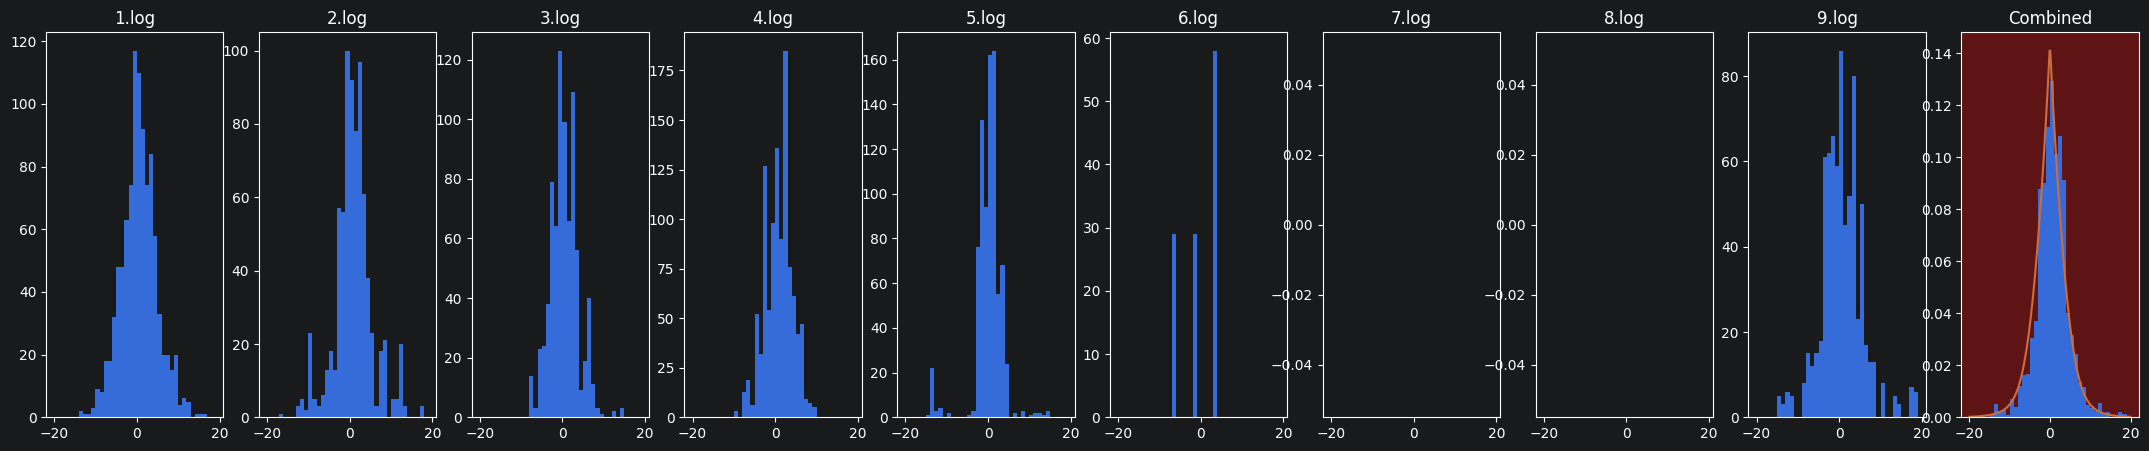

#### 285 to 315 Degrees

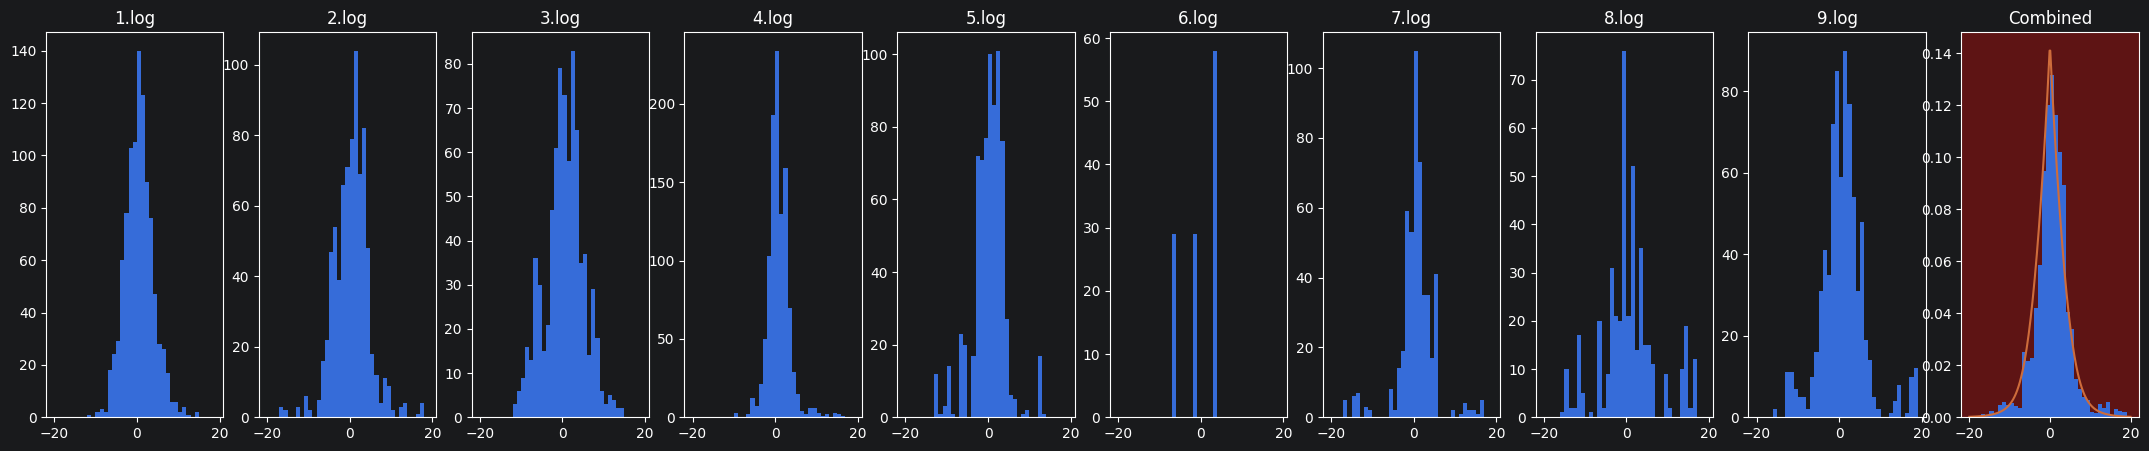

#### 315 to 345 Degrees

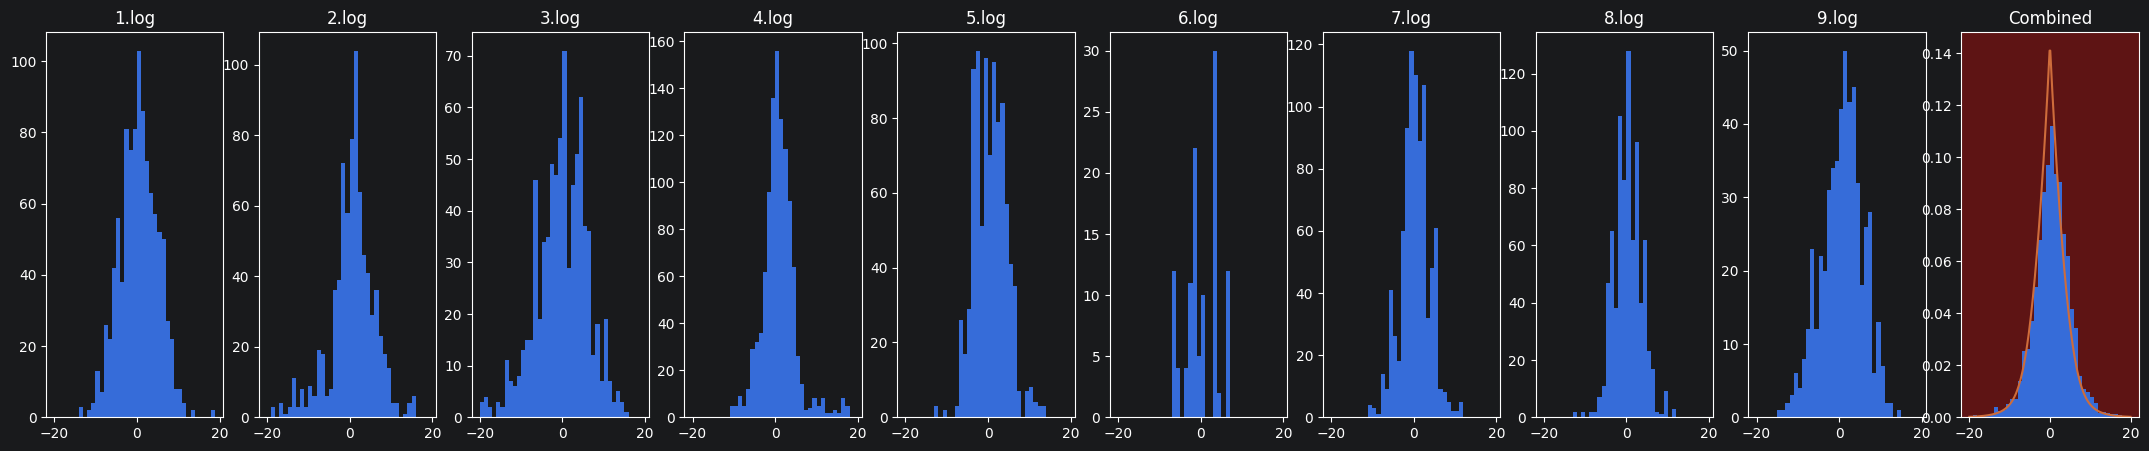

In [9]:
range_trial_rss_diffs_in_blocks(range_logs, 5)

### Ten Packet Differences

The difference is taken between the current packet and the packet at the same gamma in ten transmitter-rotations' time (approximately 20 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

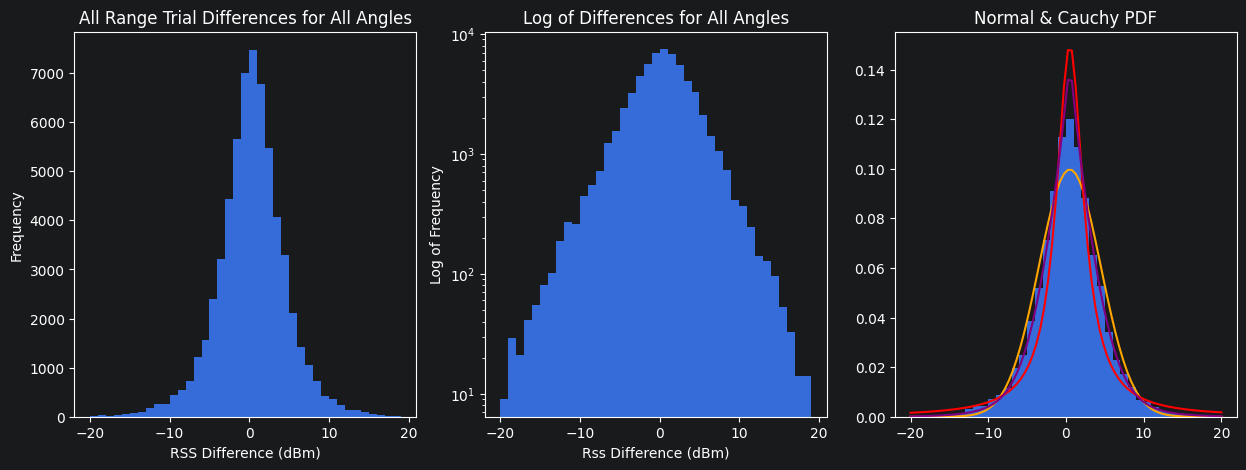

In [10]:
diffs_10 = combined_rss_at_gamma_analysis(range_logs, 10)

#### -15 to 15 Degrees

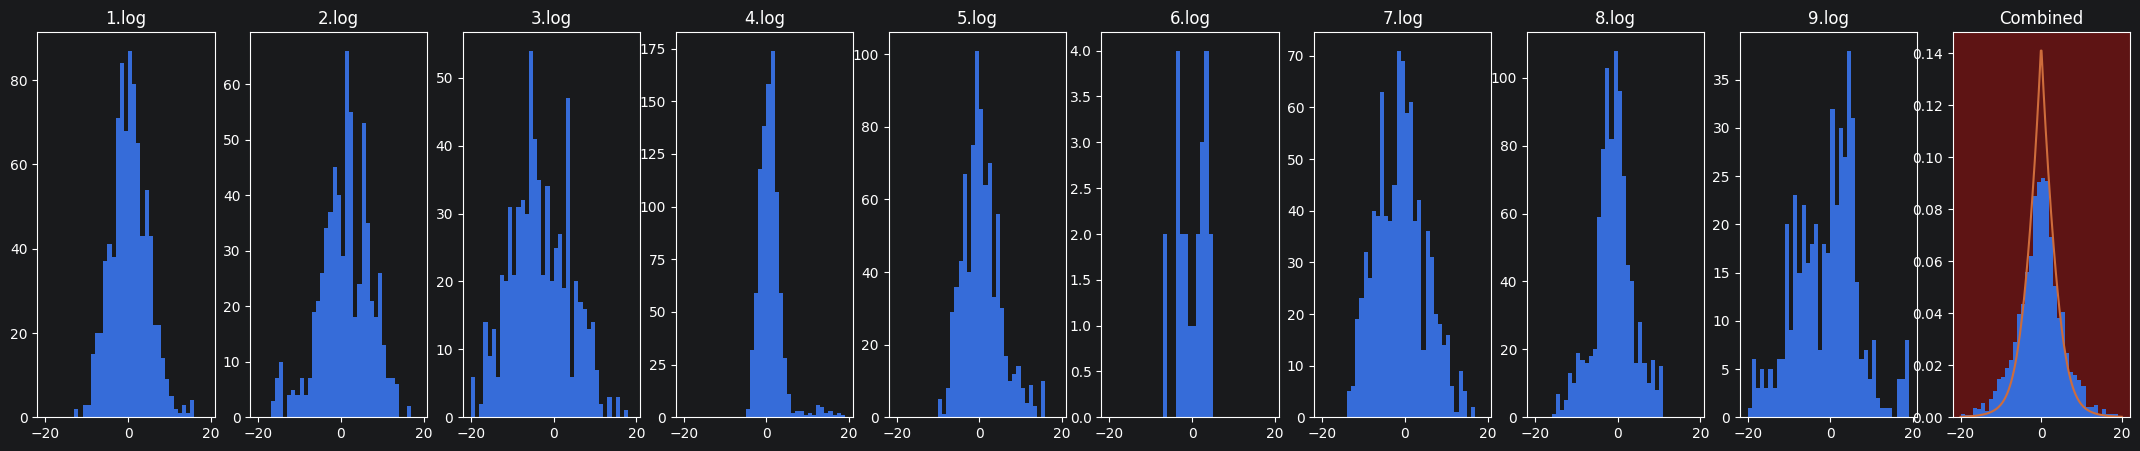

#### 15 to 45 Degrees

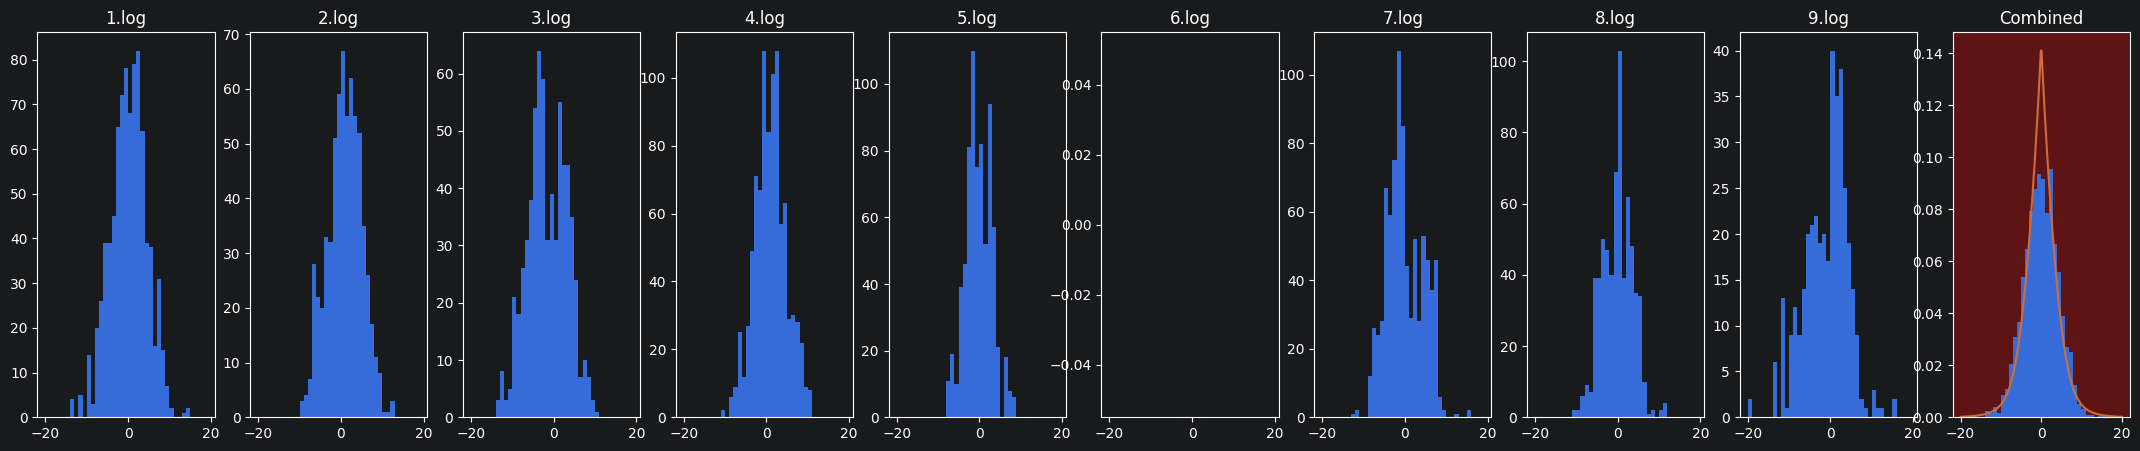

#### 45 to 75 Degrees

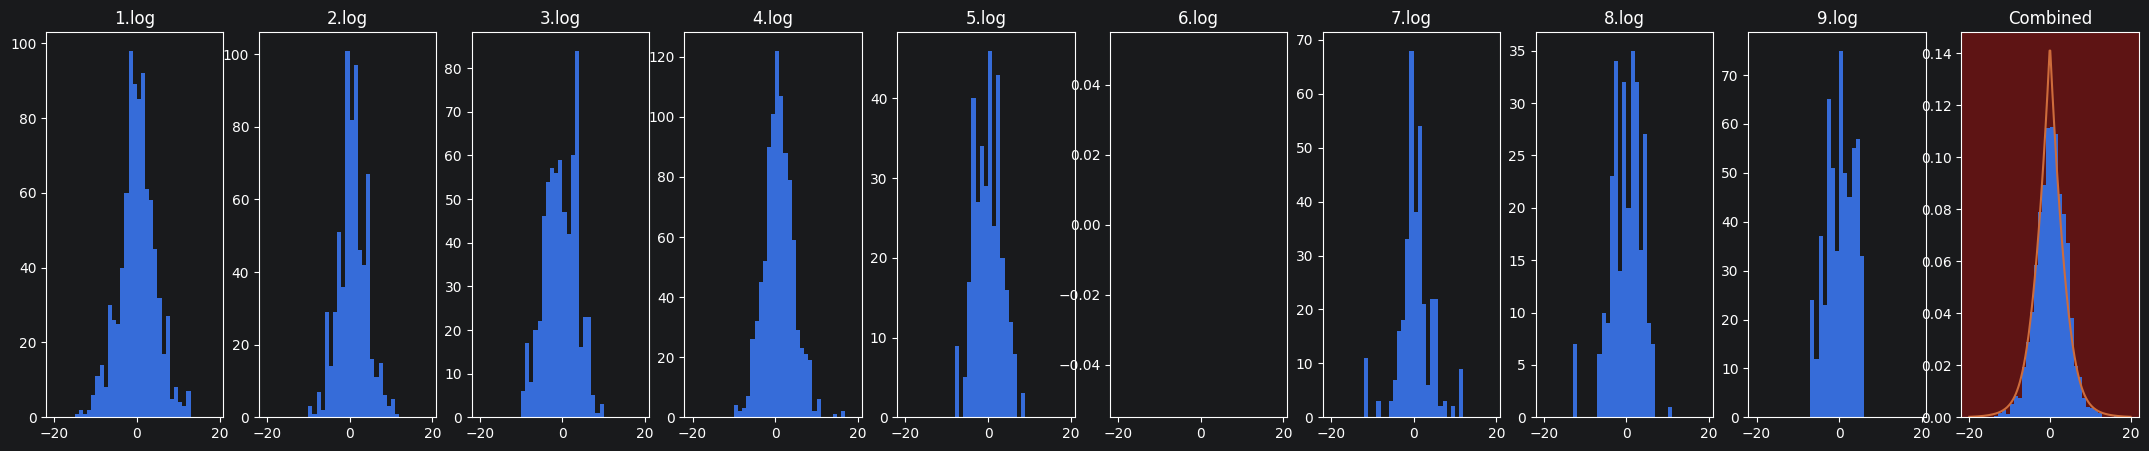

#### 75 to 105 Degrees

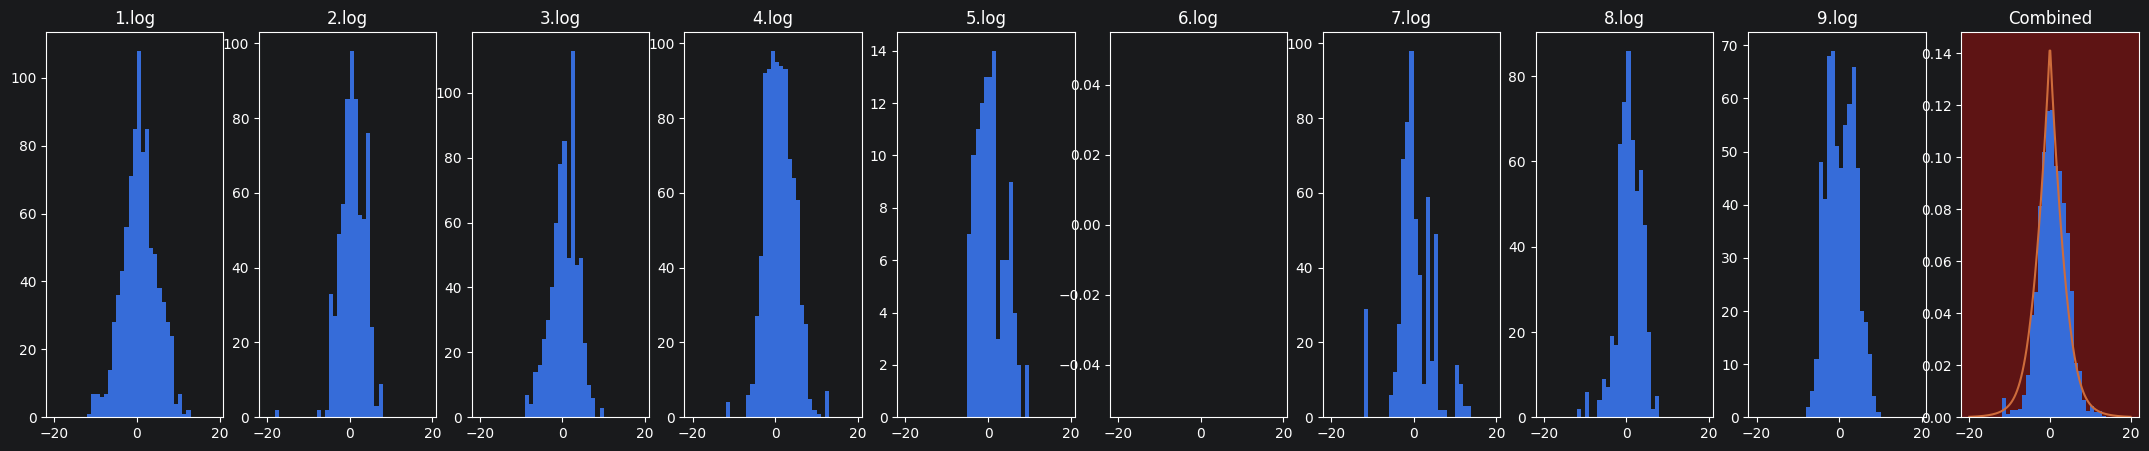

#### 105 to 135 Degrees

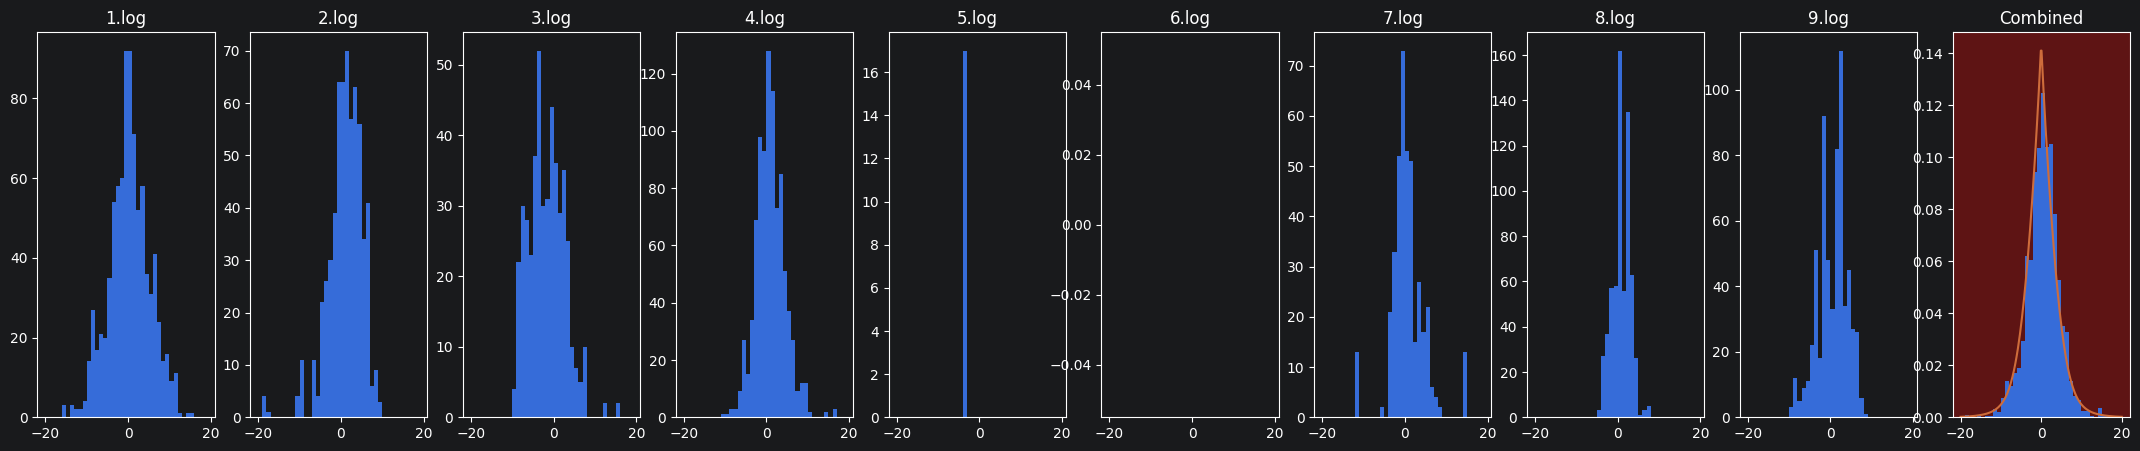

#### 135 to 165 Degrees

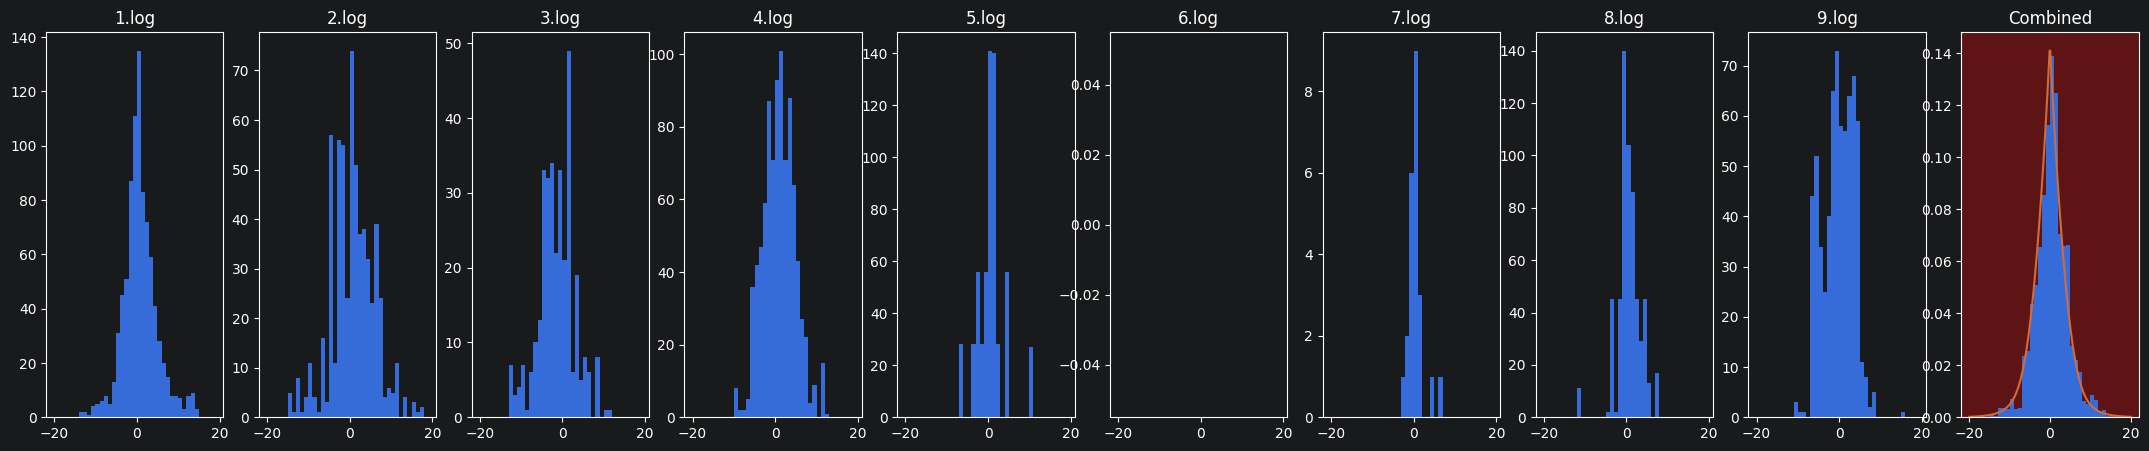

#### 165 to 195 Degrees

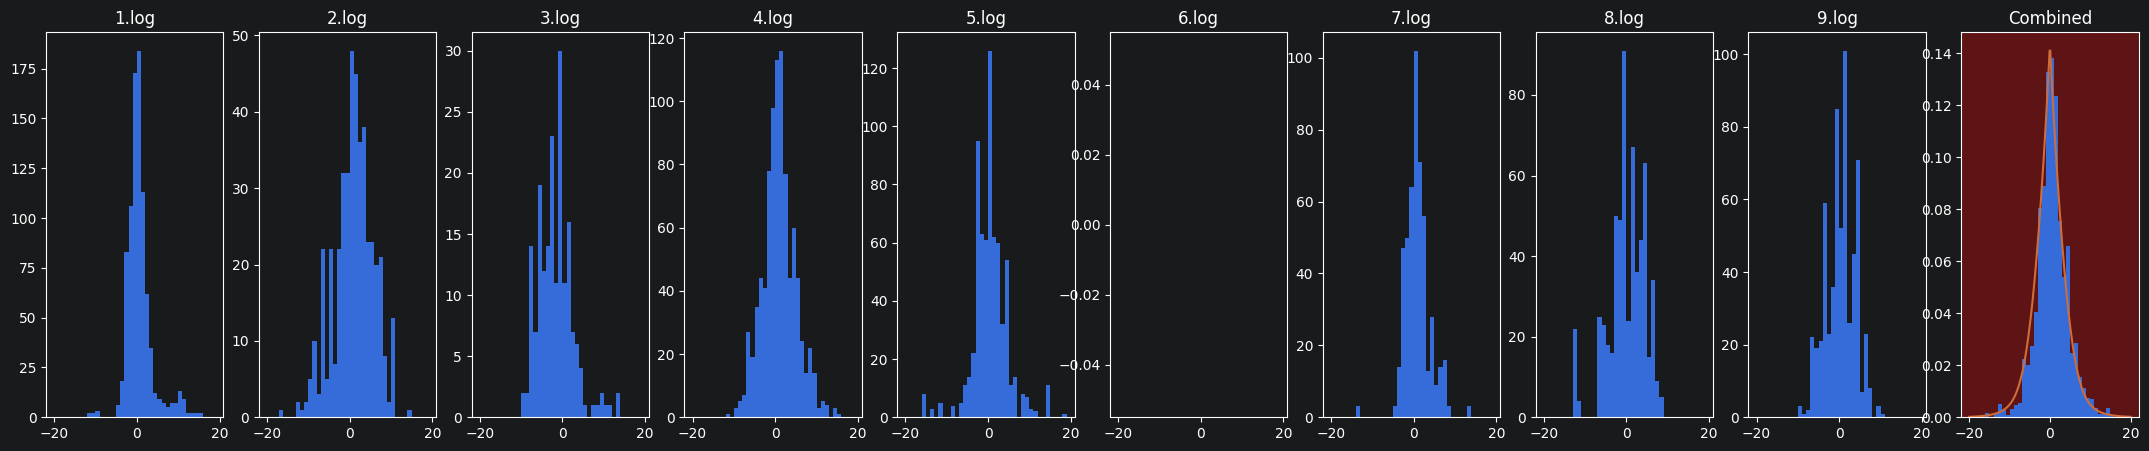

#### 195 to 225 Degrees

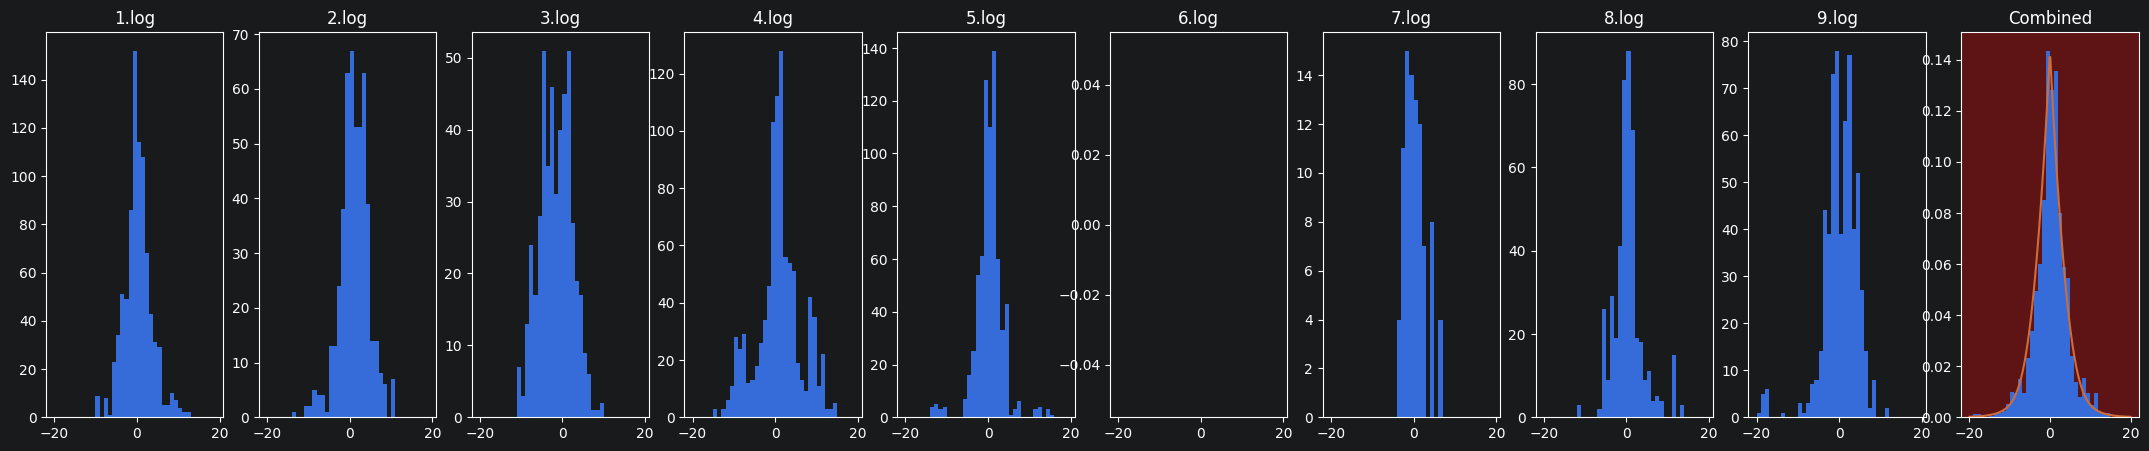

#### 225 to 255 Degrees

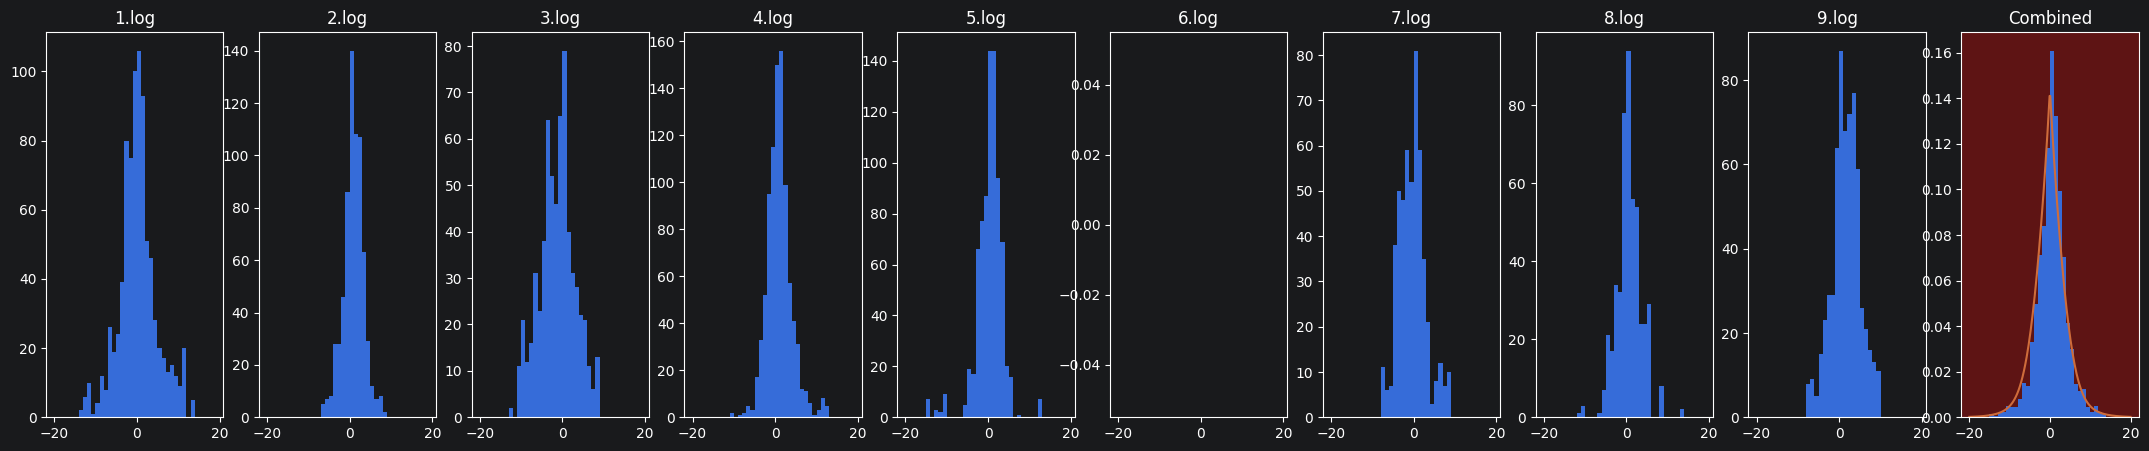

#### 255 to 285 Degrees

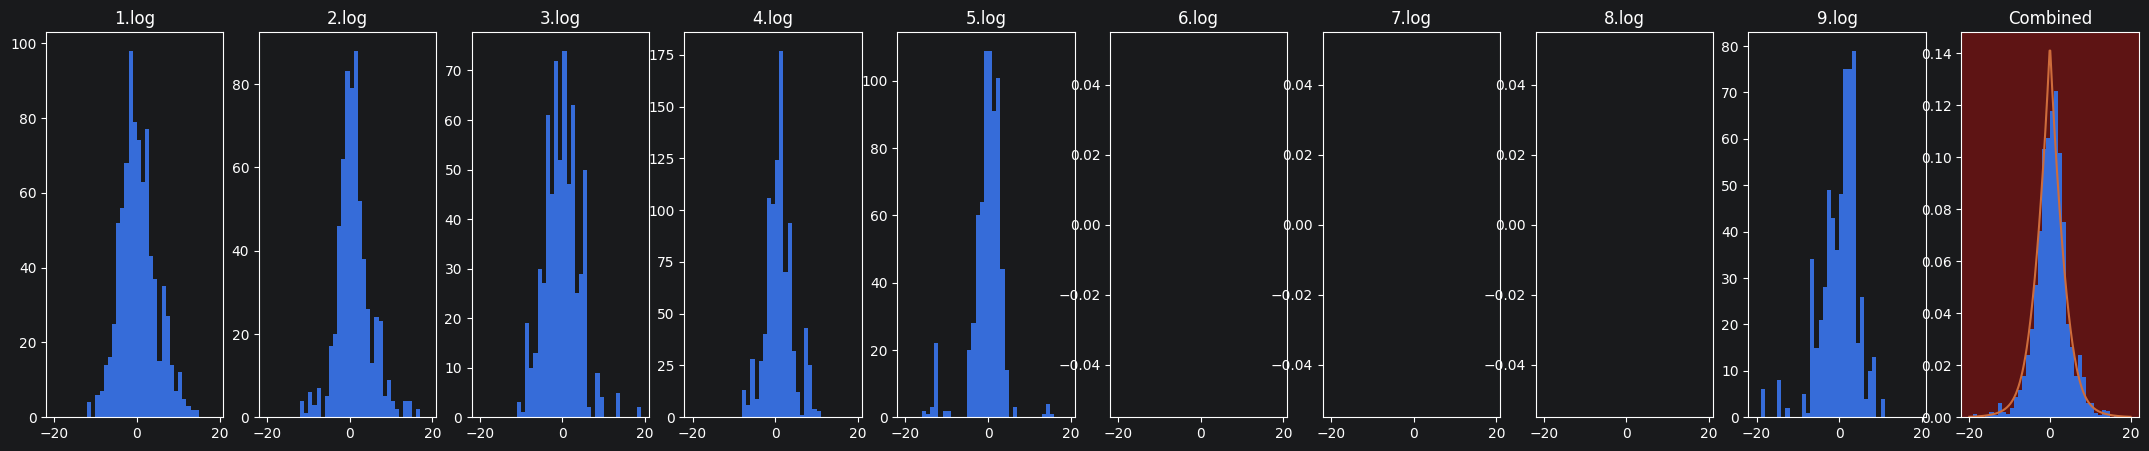

#### 285 to 315 Degrees

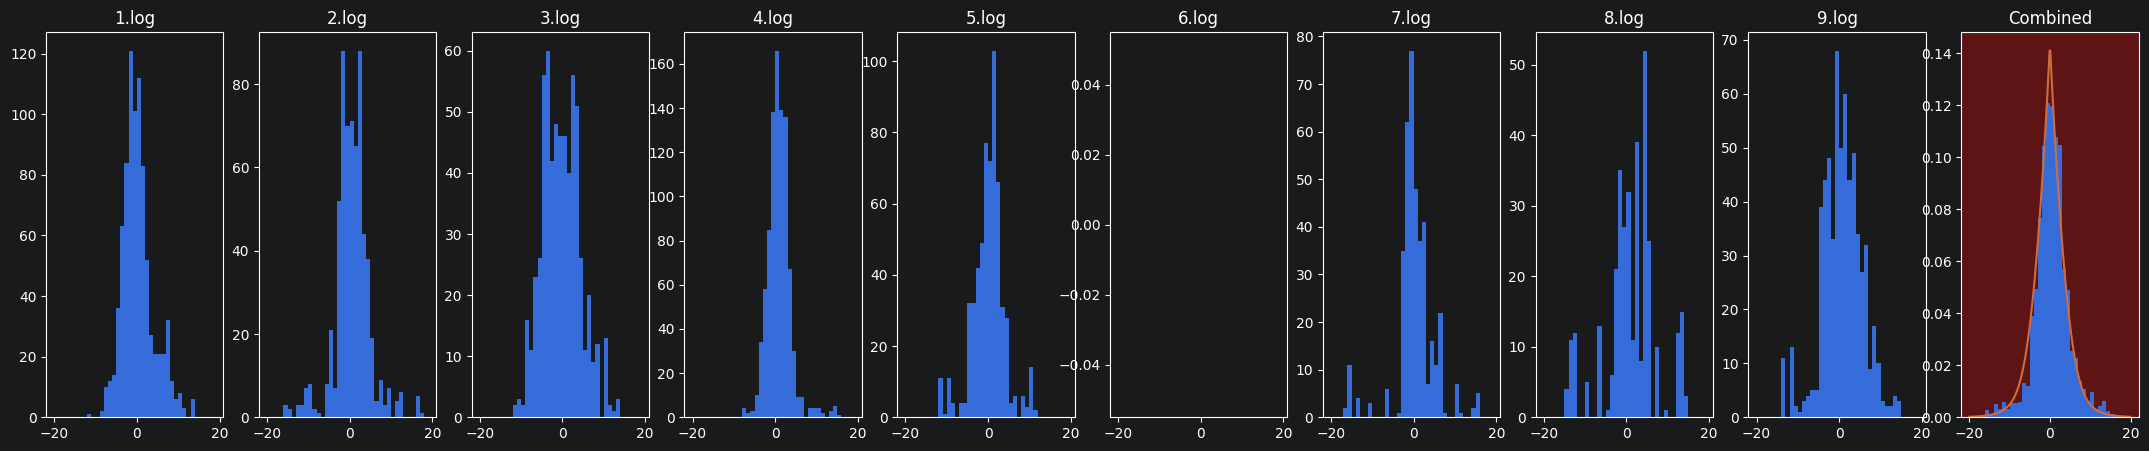

#### 315 to 345 Degrees

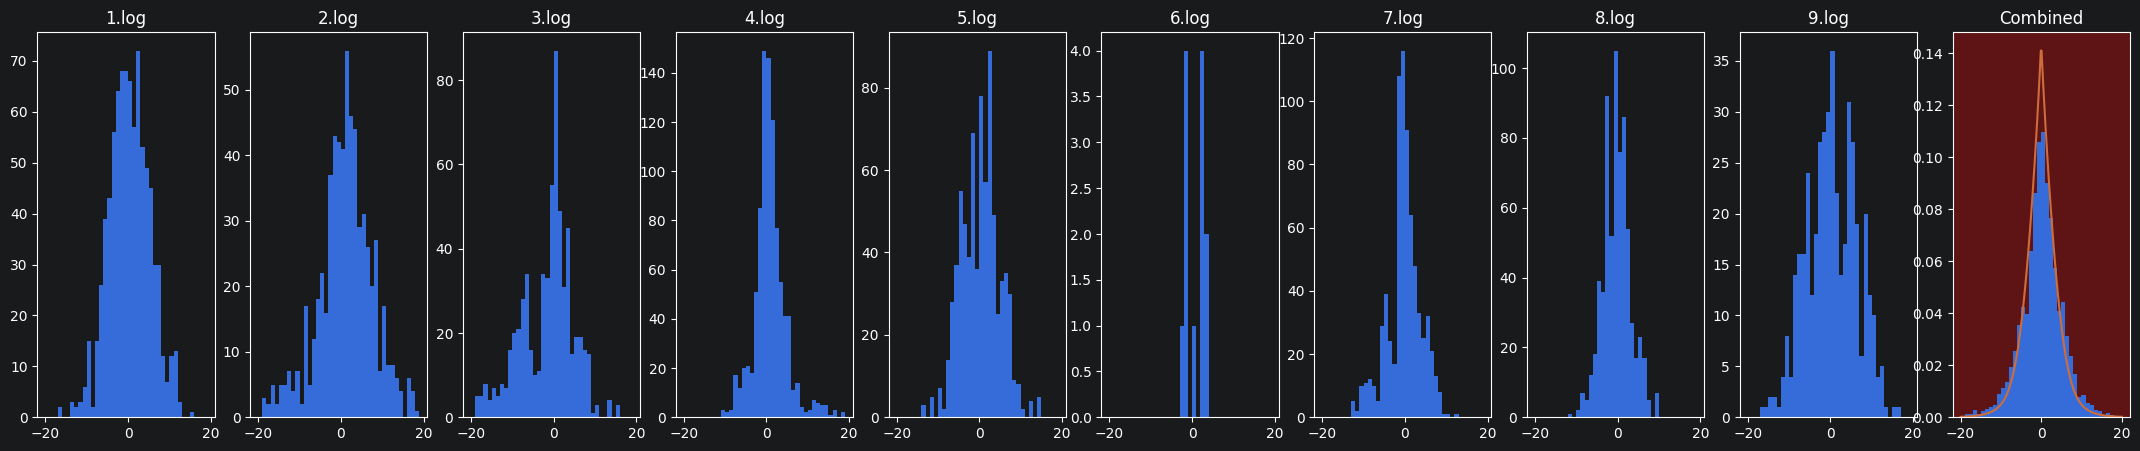

In [11]:
range_trial_rss_diffs_in_blocks(range_logs, 10)

### K-Means

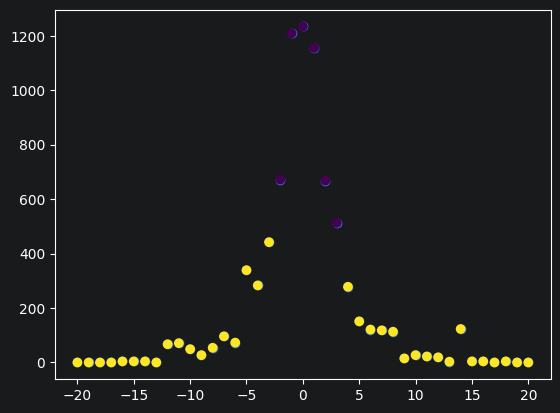

In [12]:
from sklearn.cluster import KMeans

freq_diff = [0] * 41 # [20] is diff of 0
rss = [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

for diff in diffs:
    try:
        freq_diff[diff + 20] += 1
    except:
        pass

plt.scatter(rss, freq_diff)

data = list(zip(rss, freq_diff))

kmeans = KMeans(n_clusters=2)
kmeans.fit(np.array(freq_diff).reshape(-1,1))

plt.scatter(rss, freq_diff, c=kmeans.labels_)

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 12 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.03,0.02,-0.02,0.07,0.0,0.0,52123.52,38106.63,1.0
std_posterior,1.66,0.02,1.64,1.69,0.0,0.0,52387.22,34933.28,1.0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 11 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.14,0.16,-0.16,0.44,0.0,0.0,54051.60,37894.44,1.0
std_posterior,7.44,0.12,7.21,7.65,0.0,0.0,54448.42,37178.58,1.0


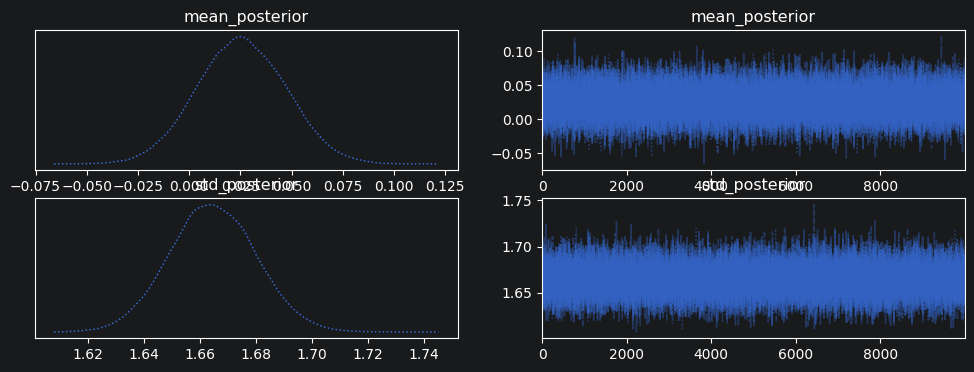

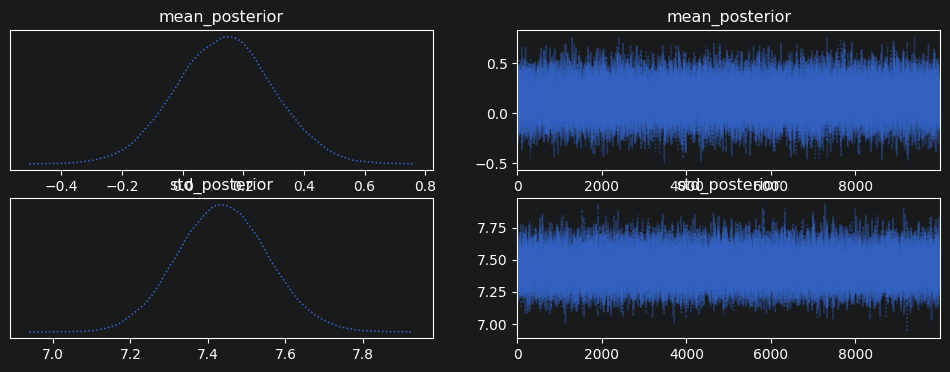

In [13]:
import pymc as pm
import arviz as az

diffs_pink = []

# filter out all "narrow" values
for diff in diffs:
    if -3 <= diff <= 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-3, upper=3)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-5, upper=5)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_pink = pm.sample(10_000, chains=5)

az.plot_trace(trace_pink, combined=True)
summary_pink = az.summary(trace_pink, round_to=2)
display(summary_pink)

diffs_pink = []

# filter out all "narrow" values
for diff in diffs:
    if diff < -3 or diff > 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-10, upper=10)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-17, upper=17)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_yellow = pm.sample(10_000, chains=5)

az.plot_trace(trace_yellow, combined=True)
summary_yellow = az.summary(trace_yellow, round_to=2)
display(summary_yellow)

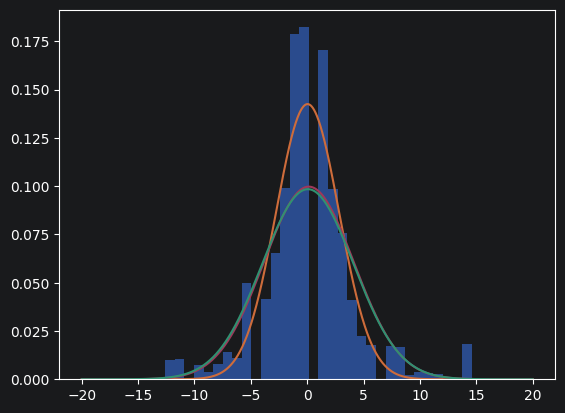

In [14]:
# plt.figure(figsize=(30, 30))
plt.hist(diffs, bins=40, alpha=0.6, density=True)

y_all = norm.pdf(x_axis, summary_pink.loc["mean_posterior", "mean"], 2.8)
y_wide = norm.pdf(x_axis, summary_yellow.loc["mean_posterior", "mean"],4.0)

plt.plot(x_axis, y_all)
plt.plot(x_axis, y_wide)

# normal over all diffs
all_mu, all_std = norm.fit(diffs)
all_norm = norm.pdf(x_axis, all_mu, all_std)
plt.plot(x_axis, all_norm)

plt.show()

## Combined Model

Hopefully this automates how to find the parameters of a mixed model.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, mean, sigma]


Output()

Sampling 3 chains for 1_000 tune and 700 draw iterations (3_000 + 2_100 draws total) took 35 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'mean'}>,
        <Axes: title={'center': 'mean'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

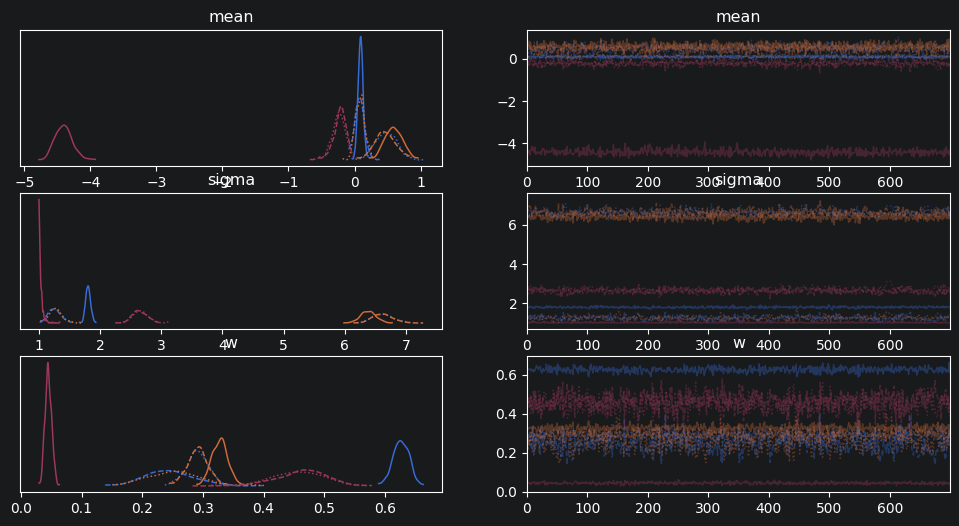

In [16]:
import pymc as pm
import arviz as az

mix_bee_model = pm.Model()

with mix_bee_model:
    # w = pm.Beta("w", alpha=1, beta=1)
    w = pm.Dirichlet("w", a=np.ones(3))
    mean = pm.Normal("mean", mu=0, sigma=1, shape=3)
    # sigma = pm.HalfNormal("sigma", sigma=5, shape=3)
    sigma = pm.Uniform("sigma", lower=1, upper=15, shape=3)

    components = pm.Normal.dist(mu=mean, sigma=sigma, shape=3)

    y = pm.Mixture("y", w=w, comp_dists=components, observed=diffs)

with mix_bee_model:
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

az.summary(trace)
az.plot_trace(trace)

In [17]:
display(az.summary(trace))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean[0],0.216,0.213,-0.046,0.650,0.109,0.047,5.0,42.0,1.66
mean[1],0.381,0.251,-0.031,0.765,0.126,0.029,5.0,41.0,1.73
mean[2],-1.622,1.971,-4.556,-0.067,1.130,0.400,5.0,36.0,1.67
sigma[0],3.228,2.414,1.104,6.800,1.385,0.491,4.0,63.0,2.37
sigma[1],4.758,2.470,1.127,6.827,1.416,0.500,4.0,42.0,2.03
sigma[2],2.114,0.773,1.000,2.821,0.440,0.153,5.0,52.0,1.67
w[0],0.388,0.172,0.204,0.648,0.098,0.034,4.0,36.0,1.96
w[1],0.291,0.042,0.202,0.353,0.018,0.008,5.0,52.0,1.53
w[2],0.321,0.198,0.035,0.515,0.112,0.038,5.0,37.0,1.67


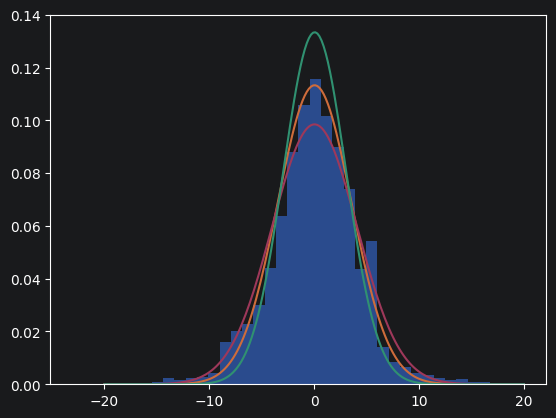

In [19]:
# plt.figure(figsize=(30, 30))
plt.hist(diffs_5, bins=40, alpha=0.6, density=True)
x_axis = np.linspace(-20, 20, 40*5)
y1 = norm.pdf(x_axis, 0.038, 3.521)
y2 = norm.pdf(x_axis, 0.030, 4.051)
y3 = norm.pdf(x_axis, 0.047, 2.991)
# y4 = norm.pdf(x_axis, 0, 20)
# y5 = cauchy.pdf(x_axis, scale=2.183)

mix = 0.333 * y1 + 0.51 * y2 + 0.157 * y3

plt.plot(x_axis, y1)
plt.plot(x_axis, y2)
plt.plot(x_axis, y3)
# plt.plot(x_axis, y4)
# plt.plot(x_axis, y5)

plt.show()

## Cauchy Distribution

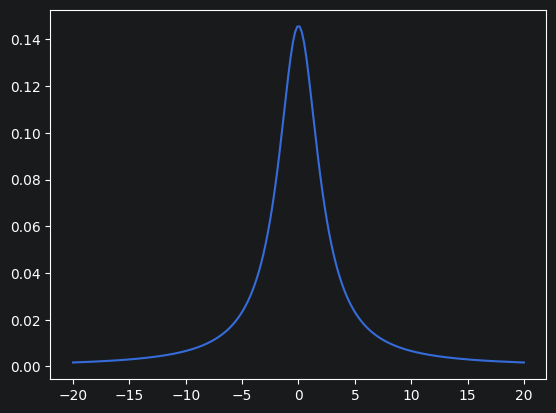

In [20]:
from scipy.stats import cauchy

x_axis = np.linspace(-20, 20, 40*5)
y_e1 = cauchy.pdf(x_axis, scale=2.183)

plt.plot(x_axis, y_e1)
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.855,0.008,1.839,1.87,0.0,0.0,2295.0,4235.0,1.0


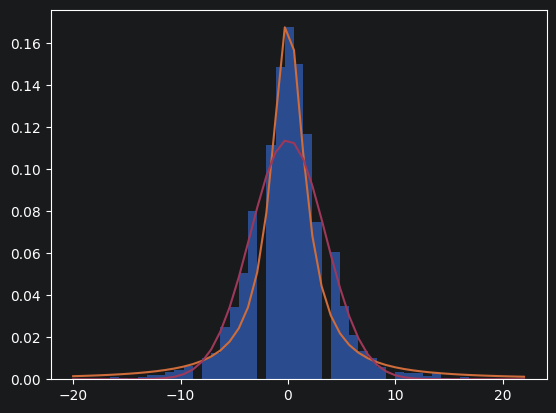

In [21]:
from BleFinley.pymc_learning import *

learn_cauchy(diffs_0)

In [ ]:
learn_cauchy(diffs_5)

In [ ]:
learn_cauchy(diffs_10)

## Cauchy and Normal Mixture Model

In [ ]:
learn_cauchy_norm_mix(diffs_5)

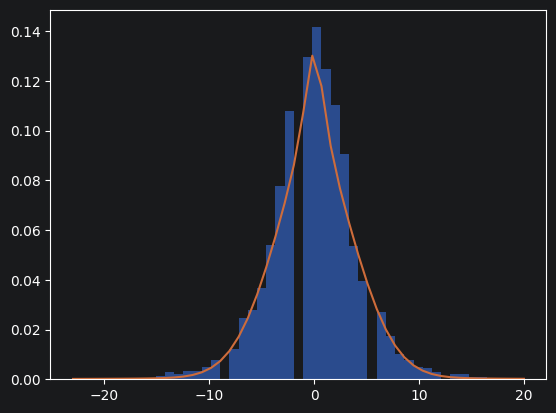

In [26]:
# plot PDF over histogram
x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

w = 0.803
c = cauchy.pdf(x_vals, scale=1.234)
n = norm.pdf(x_vals, 0, 3.980)

mix = w * n + (1 - w) * c

plt.plot(x_vals, mix)
plt.show()

#### Manual Parameter Experimentation

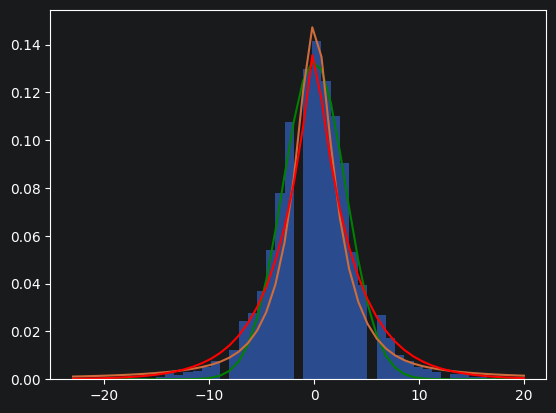

In [25]:
from scipy.stats import laplace

x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

c = cauchy.pdf(x_vals, scale=2.123)
n = norm.pdf(x_vals, 0, 3)
l = laplace.pdf(x_vals, loc=0, scale=3.5)

mix = 0.1 * n + 0.9 * c
# mix = (1 - 10**-10) * n + 10**-10 * c

# plt.plot(x_vals, c, 'red')
plt.plot(x_vals, n, 'green')
plt.plot(x_vals, mix)
plt.plot(x_vals, l, 'red')
plt.show()

### Laplace

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,3.01,0.011,2.99,3.031,0.0,0.0,2495.0,3965.0,1.0


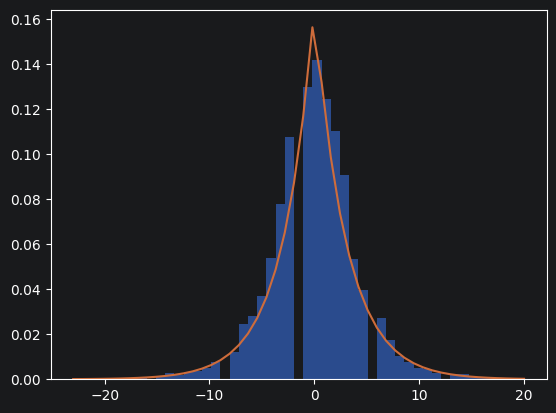

In [23]:
learn_laplace(diffs_5)

#### Laplace and Normal Mixture

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 220 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.139,0.026,3.092,3.189,0.000,0.0,3599.0,4555.0,1.0
sigma,3.463,0.042,3.385,3.544,0.001,0.0,4323.0,5303.0,1.0
w[0],0.352,0.013,0.327,0.376,0.000,0.0,4549.0,5565.0,1.0
w[1],0.648,0.013,0.624,0.673,0.000,0.0,4549.0,5565.0,1.0


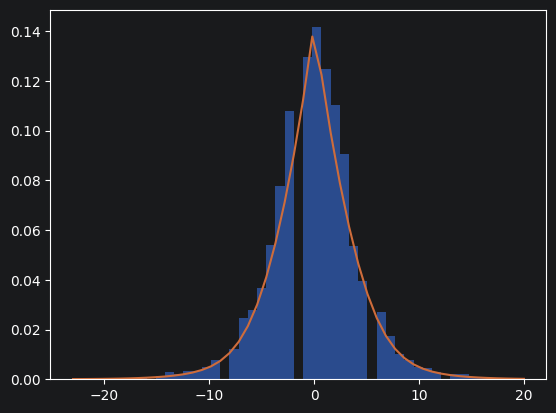

In [24]:
learn_laplace_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 268 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,2.997,0.023,2.955,3.041,0.000,0.0,3955.0,5163.0,1.0
sigma,2.913,0.035,2.848,2.978,0.001,0.0,4741.0,5186.0,1.0
w[0],0.303,0.013,0.277,0.327,0.000,0.0,4526.0,5519.0,1.0
w[1],0.697,0.013,0.673,0.723,0.000,0.0,4526.0,5519.0,1.0


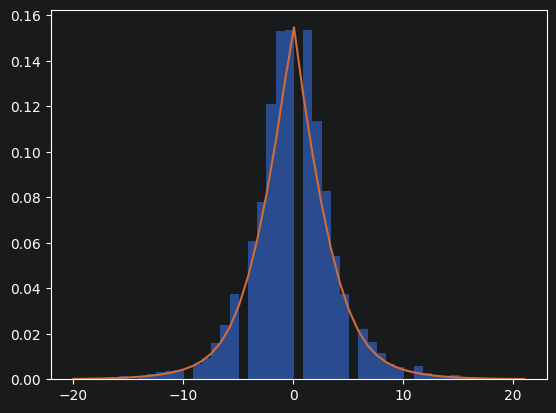

In [22]:
learn_laplace_norm_mix(diffs_2)